In [11]:
import sys
print ("Python:", sys.version)

Python: 3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]


In [12]:
libraries = [
    "torch", "transformers", "huggingface_hub", 
    "Bio", "pandas", "numpy", "scipy", 
    "sklearn", "matplotlib", "seaborn"
    ]

print("\n── Library versions ──")
for lib in libraries:
    try:
        mod = __import__(lib)
        version = getattr(mod, "__version__", "version unknown")
        print(f"  ✓  {lib:<20} {version}")
    except ImportError:
        print(f"  ✗  {lib:<20} NOT FOUND")


── Library versions ──
  ✓  torch                2.11.0


/opt/anaconda3/envs/mrnabert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✓  transformers         4.32.0
  ✓  huggingface_hub      0.36.2
  ✓  Bio                  1.87
  ✓  pandas               2.3.3
  ✓  numpy                2.2.6
  ✓  scipy                1.15.3
  ✓  sklearn              1.7.2
  ✓  matplotlib           3.10.9
  ✓  seaborn              0.13.2


In [13]:
# Line 3: Check if a GPU is available (important for mRNABERT — speeds things up a lot)
import torch
print(f"\n── Hardware ──")
print(f"  CUDA (GPU) available:  {torch.cuda.is_available()}")
print(f"  Device count:          {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"  GPU name:              {torch.cuda.get_device_name(0)}")
else:
    print(f"  Running on:            CPU only (works, but slower)")



── Hardware ──
  CUDA (GPU) available:  False
  Device count:          0
  Running on:            CPU only (works, but slower)


In [14]:
import os

# Line 1: Check where Jupyter thinks my working directory is
print("Current working directory:")
print(os.getcwd())

# Line 2: Clone the mRNABERT GitHub repository into this folder
# The ! tells Jupyter to run this as a terminal command
!git clone https://github.com/yyly6/mRNABERT.git mRNABERT_repo

# Line 3: Verify it worked — list the files
print("\nFiles in mRNABERT_repo:")
for f in os.listdir('./mRNABERT_repo'):
    print(f"  {f}")

Current working directory:
/Users/ksusha/Desktop/Python_bachelor
fatal: destination path 'mRNABERT_repo' already exists and is not an empty directory.

Files in mRNABERT_repo:
  regression.py
  .DS_Store
  LICENSE
  requirements.txt
  classification.py
  README.md
  sample_data
  .gitignore
  figures
  .git
  run_mlm.py
  data_process


In [15]:
import os

# Line 1: Find where HuggingFace stores downloaded model files on my Mac
cache_dir = os.path.expanduser("~/.cache/huggingface/hub")
print(f"HuggingFace cache location: {cache_dir}")

# Line 2: Find the mRNABERT folder inside the cache
for root, dirs, files in os.walk(cache_dir):
    for f in files:
        if 'mRNABERT' in root or 'YYLY' in root:
            print(os.path.join(root, f))

HuggingFace cache location: /Users/ksusha/.cache/huggingface/hub
/Users/ksusha/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/a1eb7df25804d23f08646e1cb996b234d7208a40/configuration_bert.py
/Users/ksusha/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/a1eb7df25804d23f08646e1cb996b234d7208a40/tokenizer_config.json
/Users/ksusha/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/a1eb7df25804d23f08646e1cb996b234d7208a40/special_tokens_map.json
/Users/ksusha/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/a1eb7df25804d23f08646e1cb996b234d7208a40/config.json
/Users/ksusha/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/a1eb7df25804d23f08646e1cb996b234d7208a40/bert_layers.py
/Users/ksusha/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/a1eb7df25804d23f08646e1cb996b234d7208a40/tokenizer.json
/Users/ksusha/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/a1eb7df25804d23f08646e1cb996b234d7208a40/bert_padding.py
/Users/ksusha/.cac

In [16]:
import os
import shutil

# Line1: Define source (cache) and destination (project folder)
cache_path = os.path.expanduser(
    "~/.cache/huggingface/hub/models--YYLY66--mRNABERT/snapshots/"
    "a1eb7df25804d23f08646e1cb996b234d7208a40"
)
dest = "./mRNAbert_model"

# Line2: Create destination folder
os.makedirs(dest, exist_ok=True)

# Line3: Copy all model files there
files_to_copy = [
    "bert_layers.py",
    "bert_padding.py", 
    "flash_attn_triton.py",
    "configuration_bert.py",
    "config.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "vocab.txt",
    "pytorch_model.bin",
    "generation_config.json"
]

for fname in files_to_copy:
    src = os.path.join(cache_path, fname)
    dst = os.path.join(dest, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✓ copied {fname}")
    else:
        print(f"✗ NOT FOUND: {fname}")

# Line4: Create __init__.py to make it a proper Python package
with open(os.path.join(dest, "__init__.py"), "w") as f:
    f.write("")
print("\n✓ Created __init__.py")

# Line5: List what I have
print("\nFiles in mRNAbert_model:")
for f in sorted(os.listdir(dest)):
    print(f"  {f}")

✓ copied bert_layers.py
✓ copied bert_padding.py
✓ copied flash_attn_triton.py
✓ copied configuration_bert.py
✓ copied config.json
✓ copied tokenizer.json
✓ copied tokenizer_config.json
✓ copied special_tokens_map.json
✓ copied vocab.txt
✓ copied pytorch_model.bin
✓ copied generation_config.json

✓ Created __init__.py

Files in mRNAbert_model:
  __init__.py
  __pycache__
  bert_layers.py
  bert_padding.py
  config.json
  configuration_bert.py
  flash_attn_triton.py
  generation_config.json
  pytorch_model.bin
  special_tokens_map.json
  tokenizer.json
  tokenizer_config.json
  vocab.txt


In [17]:
import sys
import os
import torch


# Line1: Add the PARENT folder to Python's path -> Python needs to see 'mRNAbert_model' as a package inside Python_bachelor
# so the relative imports (.bert_padding, .flash_attn_triton) resolve correctly
sys.path.insert(0, '/Users/ksusha/Desktop/Python_bachelor')

# Line2: Import the custom classes from the package
from mRNAbert_model.bert_layers import BertForMaskedLM
from mRNAbert_model.configuration_bert import BertConfig
from transformers import AutoTokenizer

print("Custom classes imported successfully")

# Line3: Load config from our local folder
model_path = './mRNAbert_model'
config = BertConfig.from_pretrained(model_path)
print(f"Config loaded")
print(f" Max position embeddings: {config.max_position_embeddings}")
print(f" ALiBi starting size: {config.alibi_starting_size}")

# Line4: Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path) #from_pretrained downloads the model weights and configuration from HuggingFace, (address)
print(f"✓ Tokenizer loaded — vocab size: {tokenizer.vocab_size}")

# Line5: Load model weights
model = BertForMaskedLM.from_pretrained(model_path, config=config)
model.eval()

## model.train() -> training mode: some layers behave randomly — dropout randomly turns off neurons, batch normalization updates its statistics. This randomness is useful during training to prevent overfitting.
## model.eval() -> everything is deterministic. I get the same output every time for the same input.
## !If I forget this, my scores will randomly vary each time you run the code.

print(f"✓ Model loaded — {model.__class__.__name__}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Line6: Test with a short sequence
test = "ATG GAG AAG CTG TAA"
tokens = tokenizer(test, return_tensors='pt')
with torch.no_grad():
    out = model(input_ids=tokens['input_ids'])
print(f"\n✓ Test forward pass successful")
print(f"  Input tokens:  {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0].tolist())}")
print(f"  Output shape:  {out.logits.shape}")
print(f"  Expected:      (1, 7, 74)  — 1 sequence, 7 tokens, 74 vocab")

/opt/anaconda3/envs/mrnabert/lib/python3.10/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
W0624 22:41:48.049000 1701 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/opt/anaconda3/envs/mrnabert/lib/python3.10/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
You are using a model of type bert to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/Users/ksusha/Desktop/Python_bachelor/mRNAbert_model/bert_layers.py:125: UserWarning: Unable to import Triton; defaulting MosaicBERT attenti

Custom classes imported successfully
Config loaded
 Max position embeddings: 512
 ALiBi starting size: 1024
✓ Tokenizer loaded — vocab size: 74
✓ Model loaded — BertForMaskedLM
  Parameters: 113,981,258

✓ Test forward pass successful
  Input tokens:  ['[CLS]', 'ATG', 'GAG', 'AAG', 'CTG', 'TAA', '[SEP]']
  Output shape:  torch.Size([1, 7, 74])
  Expected:      (1, 7, 74)  — 1 sequence, 7 tokens, 74 vocab


In [18]:
# Line2: Quick tokenizer sanity check — does it treat codons as single tokens?
print(f"\n── Tokenizer sanity check ──")
test_seq = "ATGGAGAAGCTGTAA"   # ATG GAG AAG CTG TAA — 5 codons
tokens = tokenizer(test_seq, return_tensors='pt')
token_strings = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0].tolist())
print(f"  Input sequence:   {test_seq}")
print(f"  Tokens produced:  {token_strings}")
print(f"  Vocab size:       {tokenizer.vocab_size}")


── Tokenizer sanity check ──
  Input sequence:   ATGGAGAAGCTGTAA
  Tokens produced:  ['[CLS]', '[UNK]', '[SEP]']
  Vocab size:       74


In [19]:
# Check if TGT and TGC get different IDs (critical for LLR)
try:
    id_TGT = tokenizer.convert_tokens_to_ids('TGT')
    id_TGC = tokenizer.convert_tokens_to_ids('TGC')
    print(f"  ID for 'TGT':     {id_TGT}")
    print(f"  ID for 'TGC':     {id_TGC}")
    if id_TGT != id_TGC and id_TGT != tokenizer.unk_token_id:
        print("  ✓  Codons are distinct tokens — LLR calculation will work")
    else:
        print("  ✗  WARNING: codons may not be distinct tokens — needs investigation")

except Exception as e:
    print(f"  ✗  Tokenizer check failed: {e}")

print("\n── Done ──")

  ID for 'TGT':     39
  ID for 'TGC':     40
  ✓  Codons are distinct tokens — LLR calculation will work

── Done ──


In [20]:
# Line1: Check what the tokenizer's vocabulary actually contains
# This shows us exactly what tokens it knows about
vocab = tokenizer.get_vocab()

# Line2: Print all tokens that look like codons (3 characters, only ACGT)
print("Codon tokens in vocabulary:")
codon_tokens = [token for token in vocab.keys() 
                if len(token) == 3 and all(c in 'ACGTU' for c in token.upper())]
print(sorted(codon_tokens))
print(f"\nTotal codon tokens found: {len(codon_tokens)}")

# Line3: Print all tokens that are single nucleotides
nuc_tokens = [token for token in vocab.keys()
              if len(token) == 1 and token.upper() in 'ACGTU']
print(f"\nSingle nucleotide tokens: {nuc_tokens}")

# Line4: Print all special tokens
print(f"\nSpecial tokens: {tokenizer.all_special_tokens}")

# Line5: Now try the sequence as SPACE-SEPARATED CODONS — the most likely correct format
test_spaced = "ATG GAG AAG CTG TAA"   # same sequence, but spaces between codons
tokens_spaced = tokenizer(test_spaced, return_tensors='pt')
token_strings_spaced = tokenizer.convert_ids_to_tokens(tokens_spaced['input_ids'][0].tolist())
print(f"\nWith spaces between codons:")
print(f"  Input:  '{test_spaced}'")
print(f"  Tokens: {token_strings_spaced}")

# Line6: Also try uppercase U (RNA notation) instead of T
test_rna = "AUG GAG AAG CUG UAA"
tokens_rna = tokenizer(test_rna, return_tensors='pt')
token_strings_rna = tokenizer.convert_ids_to_tokens(tokens_rna['input_ids'][0].tolist())
print(f"\nWith RNA notation (U instead of T), space-separated:")
print(f"  Input:  '{test_rna}'")
print(f"  Tokens: {token_strings_rna}")

Codon tokens in vocabulary:
['AAA', 'AAC', 'AAG', 'AAT', 'ACA', 'ACC', 'ACG', 'ACT', 'AGA', 'AGC', 'AGG', 'AGT', 'ATA', 'ATC', 'ATG', 'ATT', 'CAA', 'CAC', 'CAG', 'CAT', 'CCA', 'CCC', 'CCG', 'CCT', 'CGA', 'CGC', 'CGG', 'CGT', 'CTA', 'CTC', 'CTG', 'CTT', 'GAA', 'GAC', 'GAG', 'GAT', 'GCA', 'GCC', 'GCG', 'GCT', 'GGA', 'GGC', 'GGG', 'GGT', 'GTA', 'GTC', 'GTG', 'GTT', 'TAA', 'TAC', 'TAG', 'TAT', 'TCA', 'TCC', 'TCG', 'TCT', 'TGA', 'TGC', 'TGG', 'TGT', 'TTA', 'TTC', 'TTG', 'TTT']

Total codon tokens found: 64

Single nucleotide tokens: ['T', 'G', 'C', 'A']

Special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']

With spaces between codons:
  Input:  'ATG GAG AAG CTG TAA'
  Tokens: ['[CLS]', 'ATG', 'GAG', 'AAG', 'CTG', 'TAA', '[SEP]']

With RNA notation (U instead of T), space-separated:
  Input:  'AUG GAG AAG CUG UAA'
  Tokens: ['[CLS]', '[UNK]', 'GAG', 'AAG', '[UNK]', '[UNK]', '[SEP]']


The option with spaces is correct, when I change all T for U I still get unknown for codons -> the model uses the seq variation with T

In [21]:
# ── Helper function 1: format a raw CDS string into space-separated codons ────

def format_cds(cds_string):
    """
    Converts 'ATGGAGAAG' → 'ATG GAG AAG'
    The CDS must have a length divisible by 3.
    Uses uppercase T (DNA notation) — never U.
    """
    # Line2: Make sure the sequence is uppercase (upper) and uses T (replace)
    cds = cds_string.upper().replace('U', 'T')

    # Line3: Check it's divisible by 3 — if not, something is wrong with the input
    if len(cds) % 3 != 0:
        raise ValueError(f"CDS length {len(cds)} is not divisible by 3. Check the sequence.") #deliberately crashes the function with an informative message

    # Line4: Split into codons of 3 and join with spaces -> list comprehension (cds[i, i=3] -> string slicing:nit extracts characters from position i up to (but not including!) i+3 -> cds[0:3] = first codon, cds[3:6] = second codon etc)
    codons = [cds[i:i+3] for i in range(0, len(cds), 3)] #generates numbers starting at 0, stepping by 3 (starting positions of each codon)
    return ' '.join(codons)   # e.g. 'ATG GAG AAG CTG TAA'

# ── Helper function 2: compute LLR for one synonymous substitution ─────────────

def compute_llr(cds_string, codon_index, wildtype_codon, mutant_codon):
    """
    Computes LLR = log P(mutant_codon | context) - log P(wildtype_codon | context)

    cds_string:     raw CDS sequence, e.g. 'ATGGAGAAGCTGTAA'
    codon_index:    which codon to score (0-based: 0 = first codon ATG, 1 = second codon and so on)
    wildtype_codon: the original codon, e.g. 'TGT'
    mutant_codon:   the synonymous variant, e.g. 'TGC'

    Returns: float (negative = model finds mutation unexpected = potentially disruptive)
    """
    # Line5: Format sequence as space-separated codons
    formatted = format_cds(cds_string) # -> get the sequence ready for tokenizer

    # Line6: Tokenize — each codon is now one token
    tokens = tokenizer(formatted, return_tensors='pt') # converts the codon string into numbers, return_tensors means "give me a PyTorch sensor" (most transformer models expect PyTorch tensors, not lists -> automatic conversion + batching so the data is ready for the model immediatly)
    input_ids = tokens['input_ids'].clone() #clone makes a copy -> This matters because I am about to modify input_ids (by inserting a [MASK]), and I don't want to accidentally modify the original.

    # Line7: The codon at index i sits at token position i+1 (because [CLS] is at 0)
    token_position = codon_index + 1

    # Line8: Double-check — the token at that position should match the wildtype codon -> if there is a mismatch, I provided a wrong codon_index and would score the wrong position
    actual_token = tokenizer.convert_ids_to_tokens([input_ids[0, token_position].item()])[0] #item() converts a one-element PyTorch tensor into a plain Python integer (for tokenozer's conversion functions)
    if actual_token != wildtype_codon:
        raise ValueError(
            f"Mismatch at position {codon_index}: "
            f"expected '{wildtype_codon}' but found '{actual_token}'. "
            f"Check the codon_index."
        )

    # Line9: Replace the codon at that position with [MASK] -> the model now sees a sequence with a hole at that position and will try to predict what belongs here
    input_ids[0, token_position] = tokenizer.mask_token_id # is the integer ID of [MASK]

    # Line10: Run the model — no gradient tracking needed for inference (onle during training) -> !always use this when using the model for prediciton
    with torch.no_grad():
        outputs = model(input_ids=input_ids) # it feeds the masked sequecne through all 12 transformer layers -> the output contains predictions for every position in the sequence 

    # Line11: Get logits at the masked position — shape: (batch_size, sequence_length, vocab_size)
    logits = outputs.logits[0, token_position, :] #[0]: first seq in batch, [token_position]: the position where you places the mask, [:]: all vocabulary entries = all 74 tokens
    # logits is now the 1D sensor of 74 numbers (one raw score per token) -> they can be any value (positive, negative)

    # Line12: Convert to log probabilities (log_softmax is numerically stable, gives the logarithm of those probabilities -> 1. probabilities of rare codons can be extremely small numbers, 2. the llr formula involves substraction of log probabilities) that sum to 1
    log_probs = torch.log_softmax(logits, dim=-1) # dim = -1: apply the softmax along the last dimension

    # Line13: Look up the log probability of the wildtype codon
    wt_id  = tokenizer.convert_tokens_to_ids(wildtype_codon)
    mut_id = tokenizer.convert_tokens_to_ids(mutant_codon)
    log_p_wt  = log_probs[wt_id].item()
    log_p_mut = log_probs[mut_id].item()

    # Line14: LLR = log P(mut) - log P(WT) = log-likelyhood ratio (as Brandes used in the paper about protein LLM (ESM1b) but for mRNA codons instead of aa)
    # Negative → model finds mutant less expected → potentially functional disruption
    llr = log_p_mut - log_p_wt
    return llr, log_p_wt, log_p_mut

# TEST: ABCB1 C3435T — the known functional synonymous mutation

# Line15: Small test sequence representing the region around ABCB1 exon 26
# In this example codon 3 (0-based) is TGT — the wildtype at position 3435 -> TGC is the synonymous variant (also encodes Cysteine) introduced by C3435T
test_cds = "ATGGAGAAGTGTGAGCTGAAG"
#  codons:   0=ATG 1=GAG 2=AAG 3=TGT 4=GAG 5=CTG 6=AAG

# Line16: Compute LLR for the C3435T change (TGT → TGC, codon index 3)
llr, log_p_wt, log_p_mut = compute_llr(
    cds_string      = test_cds,
    codon_index     = 3,          # 4th codon (0-based)
    wildtype_codon  = 'TGT',
    mutant_codon    = 'TGC'
)

# Line17: Print results with interpretation
print("mRNABERT LLR test")
print(f" Gene region: ABCB1 (example sequence)")
print(f" Change: TGT → TGC (both = Cysteine, synonymous)")
print(f" log P(TGT|context) = {log_p_wt:.4f}")
print(f" log P(TGC|context) = {log_p_mut:.4f}")
print(f" LLR = {llr:.4f}")
print()
if llr < 0:
    print("  → Negative LLR: model finds TGC less expected than TGT in this context")
    print(" Interpretation: this synonymous change disrupts codon context")
elif llr > 0:
    print("  → Positive LLR: model finds TGC more expected than TGT in this context")
else:
    print("  → LLR = 0: model treats both codons identically in this context")

mRNABERT LLR test
 Gene region: ABCB1 (example sequence)
 Change: TGT → TGC (both = Cysteine, synonymous)
 log P(TGT|context) = -6.0474
 log P(TGC|context) = -4.9665
 LLR = 1.0809

  → Positive LLR: model finds TGC more expected than TGT in this context


NOW WITH THE ABCB1 SEQUENCE 

In [22]:
from Bio import SeqIO

#Load the ABCB1 sequence from the FASTA file 

#Line1: Read the FASTA file with BioPython
record = SeqIO.read("ABCB1.fasta", "fasta")

#Line2: convert the seq onject to a plain string and make it uppercase
full_seq = str(record.seq).upper()

#Line3: print basic info -> to verify if i loaded the correct file 
print(f"Sequence ID: {record.id}")
print(f"Total length: {len(full_seq)} nucleotides")
print(f"First 60 nt: {full_seq[:60]}")
print(f"Starts with ATG: {full_seq.startswith('ATG')}")

Sequence ID: NM_000927.4
Total length: 4718 nucleotides
First 60 nt: AAACACTTGTATTACCATTTTAAAGGCTATCATTACTCTTTACCTGTGAAGAGTAGAACA
Starts with ATG: False


In [23]:
#find the CDS within the full seq 

#Line4: For this file the CDS starts at position 493 and it is 3843 nucleotides long (means that it ends at pos. 4336) -> info from NCBI annotation
cds_start = 493 #0 based index of the A in the start codon ATG
cds_end = 4336 #0 based indes of the end (includes the stop codon)

cds = full_seq[cds_start:cds_end]

#Line5: verify the CDS
print (f"\nCDS length: {len(cds)} nucleotides")
print(f"Number of codons: {len(cds) // 3}")
print(f"Starts with ATG: {cds[:3]}")
print(f"Last codon: {cds[-3:]}") #should be a stop codon(TAA, TAG, TGA)
print(f"Divisible by 3: {len(cds) % 3 == 0}")


CDS length: 3843 nucleotides
Number of codons: 1281
Starts with ATG: ATG
Last codon: TGA
Divisible by 3: True


In [24]:
#verify that codon 1144 is the C3435T mutation site 

#Line1: extract the CDS
cds_start = 493
cds_end = 4336
cds = full_seq[cds_start:cds_end]

#Line2: convert the nucleotide 3435 in the CDS (1-based) to 0-based python index
nt_position_0based = 3435 - 1

#Line3: which codon does this nucleotide belong to?
codon_index = nt_position_0based // 3
position_within_codon = nt_position_0based % 3 # -> 0 = first, 1 = second, 2 = third

#Line4: extract the codon from the CDS
wt_codon = cds[codon_index*3 : codon_index*3 + 3]

#Line5: print everything for the verification
print(f"C3435T site verification")
print(f"Nucleotide position in CDS (1-based):  3435")
print(f"Nucleotide position in CDS (0-based):  {nt_position_0based}")
print(f"Codon index (0-based): {codon_index}")
print(f"Position within codon: {position_within_codon} (0=1st, 1=2nd, 2=3rd base)")
print(f"Wildtype codon at this position: {wt_codon}")
print(f"Nucleotide at position 3434: {cds[nt_position_0based]}")
print()

C3435T site verification
Nucleotide position in CDS (1-based):  3435
Nucleotide position in CDS (0-based):  3434
Codon index (0-based): 1144
Position within codon: 2 (0=1st, 1=2nd, 2=3rd base)
Wildtype codon at this position: ATT
Nucleotide at position 3434: T



In [25]:
wt_codon = 'ATT'
mut_codon = 'ATC'

#Line1: verify that both encode the same aa
from Bio.Data import CodonTable
table = CodonTable.unambiguous_dna_by_name["Standard"]
print(f"ATT encodes: {table.forward_table['ATT']}")
print(f"ATC encodes: {table.forward_table['ATC']}")
print(f"Synonymous:  {table.forward_table['ATT'] == table.forward_table['ATC']}")

ATT encodes: I
ATC encodes: I
Synonymous:  True


In [26]:
# Line2: i need to check the third allele ATA (also encodes Ile) because mRNABERT sees all 3 in context
print(f"ATA encodes: {table.forward_table['ATA']}")
print()

ATA encodes: I



In [27]:
# Line3: print codon frequencies to unterstand which is rare -> human codon usage table (from Kazusa db, frewuency per 1000 codons)
human_codon_freq = {
    'ATT': 16.0, #Homo sapiens [gbpri]: 93487 CDS's (40662582 codons) -> intermediate freq
    'ATC': 20.8, # -> most frequent (optimal)
    'ATA': 7.5 # -> rarest 
}
print(f"Codon frequencies (per 1000 codons in human genome)")
for codon, freq in human_codon_freq.items():
    print(f" {codon} (Ile): {freq}")
print(f"  → ATC is the most common Ile codon in humans")
print(f"  → ATT is intermediate")
print(f"  → ATA is the rarest")
print()

Codon frequencies (per 1000 codons in human genome)
 ATT (Ile): 16.0
 ATC (Ile): 20.8
 ATA (Ile): 7.5
  → ATC is the most common Ile codon in humans
  → ATT is intermediate
  → ATA is the rarest



In [28]:
# sliding window LLR for seq longer than 1022 codons 

#ensure I am using the correectly loaded model (BestForMaskedLM, 113M, ALiBi) -> if there is an error 512-token, restart the kernel & run cells in order from [190]
assert model.__class__.__name__ == 'BertForMaskedLM', \
    "Wrong model loaded - restart kernel & run the correct loading cell first"
assert sum(p.numel() for p in model.parameters()) > 100_000_000, \
    "Model has too few parameters - wrong version loaded"
print (f" Model check passed: {model.__class__.__name__}, {sum(p.numel() for p in model.parameters()):,} params")


def compute_llr_windowed (cds_string, codon_index, wildtype_codon, mutant_codon, window_size = 1022):
    """
    Same as compute_llr() but handles sequences longer than the model's limit of 1022 codons.
    
    Strategy: extract a window of 'window_size' codons centered on the target codon_index, then run compute_llr on that window.
    
    The mutation's codon_index within the window is recalculated automatically.
    """

    #Line1: parse the full CDS into a list of codons 
    cds = cds_string.upper().replace('U', 'T')
    if len(cds) % 3 != 0:
        raise ValueError(f"CDS length {len(cds)} not divisible by 3")
    
    all_codons = [cds[i:i+3] for i in range (0, len(cds), 3)]
    total_codons = len(all_codons)

    print(f"Total codons number in seq: {total_codons}")
    print(f"Model maximum: {window_size}")
    print(f"Target codon index: {codon_index}")

    #Line2: if the seq fits in the model, than no window needed 
    if total_codons <= window_size:
        print(f"Sequence fits in model -> no window needed")
        return compute_llr(cds_string, codon_index, wildtype_codon, mutant_codon)

    #Line3: Seq is too long -> extract a centered window (center the window on the target codon!)
    half = window_size //2 # that means 511 codons on each side 

    #Line4: calculate the window start (center on the target codon)
    window_start = codon_index - half # good option when the target codon is somewhere in the middle of the gene
    window_start = max(0, window_start) # when the target codon at the beginning, we can get the negative score that will mean absolutely different thing that i want to do (read backwards from the end) -> use max function -> window starts at the beginning, not a negative position

    #Line5: calculate the window end 
    window_end = window_start + window_size

    #Line6: if the window goes past the seq, shift window left 
    if window_end > total_codons:
        window_end = total_codons
        window_start = window_end - window_size
        window_start = max(0, window_start)

    #Line7: extract the window as a codon list, then rejoin into a CDS string 
    window_codons = all_codons[window_start:window_end]
    window_cds = ''.join(window_codons)

    #Line8: recalculate the codon index within the window (it starts at window_start, not 0)
    local_codon_index = codon_index - window_start

    #Line9: print eindow info for verification
    print(f"\nWindow: codons {window_start} → {window_end}  ({window_end - window_start} codons)")
    print(f"Target codon position in window: {local_codon_index}")
    print(f"Codons before target: {local_codon_index}")
    print(f"Codons after target:  {window_end - window_start - local_codon_index - 1}")
    
    # Line10: Run the standard LLR on the window
    return compute_llr(window_cds, local_codon_index, wildtype_codon, mutant_codon)


 Model check passed: BertForMaskedLM, 113,981,258 params


In [29]:
#Run it for ABCB1 C3435T

print ("Computing mRNABERT LLR for ABCB1 C3435T (windowed)")

llr, log_p_wt, log_p_mut = compute_llr_windowed(
    cds_string= cds, 
    codon_index= 1144, 
    wildtype_codon= 'ATT', 
    mutant_codon= 'ATC'
)

#Line1: print results 
print(f"\n RESULT")
print(f"Gene: ABCB1/MDR1")
print(f"Mutation: C3435T (exon 26, codon 1144)")
print(f"Codon change: ATT -> ATC (both encode Ile)")
print(f"\n log P(ATT): {log_p_wt:.4f}")
print(f"\n log P(ATC): {log_p_mut:.4f}")
print(f"\n LLR: {llr:.4f}")
print()

if llr < 0:
    print(f"Negative LLR: mRNABERT finds ATC less expected than ATT here")
    print(f"Consistent with ATT being locally preferred codon")

elif llr > 0:
    print(f"Positive LLR: mRNABERT finds ATC more expected than ATT here")
    print(f"ATC is the globally most common Ile codon (20.8/1000), so the model may prefer it regardless of local context")

print(f"\n Also scoring ATT -> ATA (rarest Ile codon, for comparison)")
llr_ata, _, _ = compute_llr_windowed(
    cds_string= cds, 
    codon_index= 1144, 
    wildtype_codon= 'ATT', 
    mutant_codon= 'ATA'
)
print (f"LLR for ATT -> ATA: {llr_ata:.4f}")
print()

print(f"Summary")
print(f"ATT -> ATC: {llr:.4f}")
print(f"ATT -> ATA: {llr_ata:.4f}")
print(f"Expected ranking: ATA should score lower (= more negative) than ATC, because ATA is the rarest Ile codon in humans (7.5/1000 vs 20.8/1000)")


Computing mRNABERT LLR for ABCB1 C3435T (windowed)
Total codons number in seq: 1281
Model maximum: 1022
Target codon index: 1144

Window: codons 259 → 1281  (1022 codons)
Target codon position in window: 885
Codons before target: 885
Codons after target:  136

 RESULT
Gene: ABCB1/MDR1
Mutation: C3435T (exon 26, codon 1144)
Codon change: ATT -> ATC (both encode Ile)

 log P(ATT): -2.1659

 log P(ATC): -3.6585

 LLR: -1.4926

Negative LLR: mRNABERT finds ATC less expected than ATT here
Consistent with ATT being locally preferred codon

 Also scoring ATT -> ATA (rarest Ile codon, for comparison)
Total codons number in seq: 1281
Model maximum: 1022
Target codon index: 1144

Window: codons 259 → 1281  (1022 codons)
Target codon position in window: 885
Codons before target: 885
Codons after target:  136
LLR for ATT -> ATA: -1.3689

Summary
ATT -> ATC: -1.4926
ATT -> ATA: -1.3689
Expected ranking: ATA should score lower (= more negative) than ATC, because ATA is the rarest Ile codon in humans

# Now the whole exon 26

In [30]:
import pandas as pd 
from Bio.Data import CodonTable 

#Setup

#Line1: load the standard genentic code table -> this maps every codon to its aa
table = CodonTable.unambiguous_dna_by_name["Standard"]

#Line2: build the reverse lookup - aa -> list of all codons that encode it
aa_to_codons = {}
for codon, aa in table.forward_table.items():
    aa_to_codons.setdefault(aa, []).append(codon)

#Line3: Human codon frequency tabel from kazusa db (per 1000 codons) -> full table (all 64 codons)
codon_freq = {
    'TTT':17.6,'TTC':20.3,'TTA': 7.7,'TTG':12.9,
    'CTT':13.2,'CTC':19.6,'CTA': 7.2,'CTG':39.6,
    'ATT':16.0,'ATC':20.8,'ATA': 7.5,'ATG':22.0,
    'GTT':11.0,'GTC':14.5,'GTA': 7.1,'GTG':28.1,
    'TCT':15.2,'TCC':17.7,'TCA':12.2,'TCG': 4.4,
    'CCT':17.5,'CCC':19.8,'CCA':16.9,'CCG': 6.9,
    'ACT':13.1,'ACC':18.9,'ACA':15.1,'ACG': 6.1,
    'GCT':18.4,'GCC':27.7,'GCA':15.8,'GCG': 7.4,
    'TAT':12.2,'TAC':15.3,'TAA': 1.0,'TAG': 0.8,
    'CAT':10.9,'CAC':15.1,'CAA':12.3,'CAG':34.2,
    'AAT':17.0,'AAC':19.1,'AAA':24.4,'AAG':31.9,
    'GAT':21.8,'GAC':25.1,'GAA':29.0,'GAG':39.6,
    'TGT':10.6,'TGC':12.6,'TGA': 1.6,'TGG':13.2,
    'CGT': 4.5,'CGC':10.4,'CGA': 6.2,'CGG':11.4,
    'AGT':15.2,'AGC':19.5,'AGA':12.2,'AGG':12.0,
    'GGT':10.8,'GGC':22.2,'GGA':16.5,'GGG':16.5,
}

print(f"Genetic code and codon frequency table loaded")
print(f"Amino acids coveren: {len(aa_to_codons)}")


#Define the scan region

#Line4: scan only 26 exon region (codons 1100 to 1200) -> this contains C3435T at codon 1144 (known positive control)
scan_start = 1100
scan_end = 1200

print(f"\n Scan region: codons {scan_start} to {scan_end-1}")
print(f" Total codons to scan: {scan_end - scan_start}")

inside_outside = 'inside' if scan_start <=1144 < scan_end else 'outside'
print(f" C3435T (codon 1144) is {inside_outside} this region")


#main scan function

def scan_synonymous_substitutions (cds, start_codon, end_codon, model, tokenizer, window_size = 1022):
    """
    For every codon in the frame [start_codon, end_codon], finds all synonymous substitutions and computes the mRNABERT LLR for each one
    Returns the data frame with one row per (codon, substitution) pair
    """

    #Line5: parse full CDS into list of codons
    cds_clean = cds.upper().replace('U', 'T')
    all_codons = [cds_clean[i: i+3] for i in range(0, len(cds_clean), 3)]
    total = len(all_codons)
    results = []

    print(f"\n Starting scan: {end_codon - start_codon} codons * avg ~2 substitutions each")
    print(f"Progress will update every 10 codons\n")

    for codon_idx in range(start_codon, end_codon):

        #Line6: get the wildtype codon at this position
        wt_codon = all_codons[codon_idx]

        #Line7: skip stop codons (not a part of the protein)
        if wt_codon not in table.forward_table:
            continue

        #Line8: get aa and all synonymous codons 
        aa = table.forward_table[wt_codon]
        syn_codons = [c for c in aa_to_codons[aa] if c != wt_codon]

        #Line9: if no synonymous codons exist, skip (e.g. Met, Trp)
        if not syn_codons:
            continue

        #Line10: calculate window for this codon 
        half = window_size //2
        wind_start = max(0, codon_idx - half)
        wind_end = wind_start + window_size
        if wind_end > total:
            wind_end = total
            wind_start = max(0, wind_end - window_size)

        window_cds = ''.join(all_codons[wind_start:wind_end])
        local_idx = codon_idx - wind_start

        #Line11: score each sSNP
        for mut_codon in syn_codons:
            try:
                llr, log_p_wt, log_p_mut = compute_llr(
                    window_cds, local_idx, wt_codon, mut_codon
                )

                #Line 12: score results with all relevant info
                results.append({
                    'codon_index': codon_idx, 
                    'wildtype_codon': wt_codon, 
                    'mutant_codon': mut_codon, 
                    'amino_acid': aa, 
                    'LLR': llr, 
                    'log_p_wt': log_p_wt, 
                    'log_p_mut': log_p_mut, 
                    'wt_freq': codon_freq.get(wt_codon, 0), 
                    'mut_freq': codon_freq.get(mut_codon, 0), 
                    'delta_freq': codon_freq.get(mut_codon, 0) - codon_freq.get(wt_codon, 0), 
                    'is_C3435T': (codon_idx == 1144 and mut_codon == 'ATC'), 
                })
            except Exception as e:
                print(f" Warning: codon {codon_idx} {wt_codon} -> {mut_codon} failed: {e}") #if one scoring fails, log it and continue
        
        #Line13: print progress every 10 codons
        if (codon_idx - start_codon) % 10 == 0:
            done = codon_idx - start_codon + 1
            total_region = end_codon - start_codon
            print(f" progress: {done}/{total_region} codons"
                  f"({100*done/total_region:.0f}%) |"
                  f"last codon: {wt_codon} at position {codon_idx}")
    
    #Line14: convert results list to a DataFrame 
    df = pd.DataFrame(results)
    print(f"\n Scan complete: {len(df)} substitutions scored")
    return df

#Run the scan

print(f" Starting 26 exon region scan")

df_exon26 = scan_synonymous_substitutions(
    cds= cds, 
    start_codon= scan_start, 
    end_codon= scan_end, 
    model= model, 
    tokenizer= tokenizer
)


#Save the results (to CSV)
df_exon26.to_csv('ABCB1_exon26_scan.csv', index= False)
print(f" \n Results saved to ABCB1_exon26_scan.csv")
print(f" Shape: {df_exon26.shape} (rows = substitutions, cols = features)")
print(f" \n First 5 rows:")
print(df_exon26.head())
print(f"\n C3435T entry:")
print(df_exon26[df_exon26['is_C3435T'] == True])



Genetic code and codon frequency table loaded
Amino acids coveren: 20

 Scan region: codons 1100 to 1199
 Total codons to scan: 100
 C3435T (codon 1144) is inside this region
 Starting 26 exon region scan

 Starting scan: 100 codons * avg ~2 substitutions each
Progress will update every 10 codons

 progress: 1/100 codons(1%) |last codon: ATA at position 1100
 progress: 11/100 codons(11%) |last codon: GCA at position 1110
 progress: 21/100 codons(21%) |last codon: ATC at position 1120
 progress: 31/100 codons(31%) |last codon: ATT at position 1130
 progress: 41/100 codons(41%) |last codon: TCA at position 1140
 progress: 51/100 codons(51%) |last codon: GAG at position 1150
 progress: 61/100 codons(61%) |last codon: CTG at position 1160
 progress: 71/100 codons(71%) |last codon: GAC at position 1170
 progress: 81/100 codons(81%) |last codon: AAA at position 1180
 progress: 91/100 codons(91%) |last codon: GTT at position 1190

 Scan complete: 262 substitutions scored
 
 Results saved to A

In [31]:
# Line1: Load the saved CSV
import pandas as pd
df_exon26 = pd.read_csv('ABCB1_exon26_scan.csv')

# Line2: Basic summary
print(f"Scan results summary")
print(f"Total substitutions scored: {len(df_exon26)}")
print(f"Codons covered: {df_exon26['codon_index'].nunique()}")
print(f"LLR range: {df_exon26['LLR'].min():.4f} to {df_exon26['LLR'].max():.4f}")
print(f"Mean LLR: {df_exon26['LLR'].mean():.4f}")
print(f"Median LLR: {df_exon26['LLR'].median():.4f}")

# Line3: Show the C3435T entry specifically
print(f"\nC3435T entry (codon 1144, ATT → ATC)")
c3435t = df_exon26[df_exon26['is_C3435T'] == True]
print(c3435t[['codon_index','wildtype_codon','mutant_codon',
              'amino_acid','LLR','wt_freq','mut_freq','delta_freq']])

# Line4: Show the 10 most negative LLR scores (most disruptive)
print(f"\n Top 10 most disruptive substitutions in exon 26")
print(df_exon26.nsmallest(10, 'LLR')[
    ['codon_index','wildtype_codon','mutant_codon','amino_acid',
     'LLR','wt_freq','mut_freq','delta_freq']
].to_string(index=False))

# Line5: Show where C3435T ranks among all scored substitutions
rank = (df_exon26['LLR'] <= c3435t['LLR'].values[0]).sum()
print(f"\nC3435T ranking")
print(f"C3435T LLR: {c3435t['LLR'].values[0]:.4f}")
print(f"Rank: {rank} out of {len(df_exon26)} substitutions")
print(f"Percentile: bottom {100*rank/len(df_exon26):.1f}%")

Scan results summary
Total substitutions scored: 262
Codons covered: 99
LLR range: -3.2454 to 2.0238
Mean LLR: -0.7424
Median LLR: -0.8391

C3435T entry (codon 1144, ATT → ATC)
     codon_index wildtype_codon mutant_codon amino_acid       LLR  wt_freq  \
112         1144            ATT          ATC          I -1.492558     16.0   

     mut_freq  delta_freq  
112      20.8         4.8  

 Top 10 most disruptive substitutions in exon 26
 codon_index wildtype_codon mutant_codon amino_acid       LLR  wt_freq  mut_freq  delta_freq
        1136            AGC          TCG          S -3.245430     19.5       4.4       -15.1
        1146            AGG          CGC          R -3.189870     12.0      10.4        -1.6
        1121            CTG          TTA          L -3.174768     39.6       7.7       -31.9
        1176            TCT          AGC          S -2.993554     15.2      19.5         4.3
        1151            GCC          GCG          A -2.952098     27.7       7.4       -20.3
  

 Positions to plot: 99


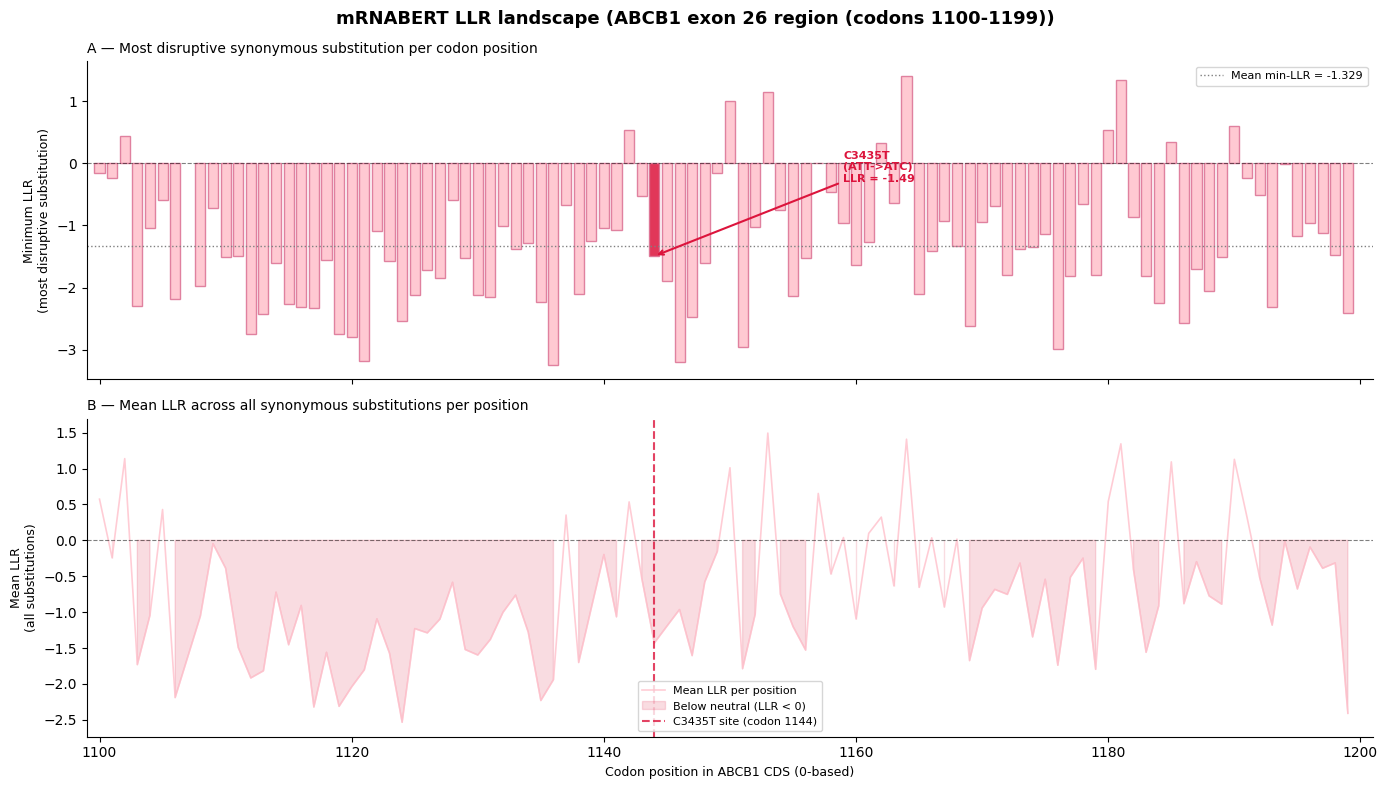

Figure saved as ABCB1_exon26_LLR_landscape.png

Figure caption statistics
Positions with min LLR < −2.0:  29 / 99
Positions with min LLR < −1.5:  47 / 99
C3435T min LLR:  -1.4926
Most disruptive position: codon 1136 (LLR = -3.2454)


In [32]:
# Now visualization 

import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches 
import numpy as np 

#Prepare data 

#Line1: for each codon position, get the min LLR across all substitutions (min LLR = the most disruptive possible change at that position) -> shows ehich positions are most sensitive 
min_llr = df_exon26.groupby('codon_index')['LLR'].min().reset_index()
min_llr.columns = ['codon_index', 'min_LLR']

#Line2: also calculate the mean LLR per position -> average sensivity 
mean_llr = df_exon26.groupby('codon_index')['LLR'].mean().reset_index()
mean_llr.columns = ['codon_index', 'mean_LLR']

#Line3: merge into one table
pos_data = min_llr.merge(mean_llr, on = 'codon_index')
print(f" Positions to plot: {len(pos_data)}")


#Create the figure 

#Line4: create the figure with 2 panels stacked vertically 
fig, (ax1, ax2) = plt.subplots (2, 1, figsize = (14,8), sharex= True)
fig.suptitle('mRNABERT LLR landscape (ABCB1 exon 26 region (codons 1100-1199))', fontsize = 13, fontweight = 'bold', y = 0.98)


#Panel 1: min LLR per position (bar chart)

#Line5: color each bar (C3435T position in red)
colors = ['crimson' if idx == 1144 else 'pink'
          for idx in pos_data['codon_index']]

#Line6: draw rthe bars 
ax1.bar(pos_data['codon_index'], pos_data['min_LLR'], color = colors, alpha = 0.85, width = 0.8, edgecolor = 'palevioletred')

#Line7: add neutral reference (a horizontal line at the LLR = 0)
ax1.axhline(0, color = 'black', linewidth = 0.8, linestyle = '--', alpha = 0.5)

#Line8: add a horizontal line at the mean LLR across all positions 
mean_all = pos_data['min_LLR'].mean()
ax1.axhline(mean_all, color = 'gray', linewidth = 1.0, linestyle = ':', label = f'Mean min-LLR = {mean_all:.3f}')

#Line9: label the C3435T bar with an arrow 
ax1.annotate('C3435T\n(ATT->ATC)\nLLR = -1.49', 
             xy = (1144, df_exon26[df_exon26['is_C3435T'] == True]['LLR'].values[0]), 
             xytext = (1144 + 15, -0.3), 
             fontsize = 8, color = 'crimson', fontweight = 'bold', 
             arrowprops = dict(arrowstyle = '->', color = 'crimson',  lw = 1.5))

#Line10: labels and formatting
ax1.set_ylabel('Minimum LLR\n(most disruptive substitution)', fontsize=9)
ax1.set_title('A — Most disruptive synonymous substitution per codon position',
              fontsize=10, loc='left')
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


#Panel 2: mean LLR per position (line plot)

# Line11: Plot mean LLR as a line
ax2.plot(pos_data['codon_index'], pos_data['mean_LLR'],
         color = 'pink', linewidth=1.2, alpha=0.8, label='Mean LLR per position')

# Line12: Fill area below zero in light red (disrupted region)
ax2.fill_between(pos_data['codon_index'], pos_data['mean_LLR'], 0,
                 where=(pos_data['mean_LLR'] < 0),
                 color='crimson', alpha=0.15, label='Below neutral (LLR < 0)')

# Line13: Mark C3435T position with a vertical line
ax2.axvline(1144, color='crimson', linewidth=1.5, linestyle='--',
            label='C3435T site (codon 1144)', alpha=0.8)

# Line14: Neutral reference line
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Line15: Labels
ax2.set_xlabel('Codon position in ABCB1 CDS (0-based)', fontsize=9)
ax2.set_ylabel('Mean LLR\n(all substitutions)', fontsize=9)
ax2.set_title('B — Mean LLR across all synonymous substitutions per position',
              fontsize=10, loc='left')
ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


#Final formatting 

# Line16: Set x-axis range to the scan region
ax2.set_xlim(scan_start - 1, scan_end + 1)

plt.tight_layout()
plt.savefig('ABCB1_exon26_LLR_landscape.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved as ABCB1_exon26_LLR_landscape.png")

# Summary statistics for the figure caption

# Line17: Print numbers I will need for the figure caption in thesis
print(f"\nFigure caption statistics")
print(f"Positions with min LLR < −2.0:  "
      f"{(pos_data['min_LLR'] < -2.0).sum()} / {len(pos_data)}")
print(f"Positions with min LLR < −1.5:  "
      f"{(pos_data['min_LLR'] < -1.5).sum()} / {len(pos_data)}")
print(f"C3435T min LLR:  "
      f"{df_exon26[df_exon26['is_C3435T']==True]['LLR'].values[0]:.4f}")
print(f"Most disruptive position: codon "
      f"{pos_data.loc[pos_data['min_LLR'].idxmin(), 'codon_index']} "
      f"(LLR = {pos_data['min_LLR'].min():.4f})")

In [33]:
#validate the second synonymous positive control: ABCB1 C1236T

#Sanity-check the codons first (0-based index)
#Line1: codon 412 in 1-based numbering = index 411 in 0-based Python splicing 
idx_1236 = 411 #C1236T -> codon 412 (Gly)
idx_3435 = 1144 #C3435T -> codon 1145 (Ile)

#read the codons actually present in your CDS and store them in variables 
codon_1236 = cds[idx_1236*3 : idx_1236*3 + 3]
codon_3435 = cds[idx_3435*3 : idx_3435*3 + 3]

print(f"Codon at idx 411 (C1236T site): {codon_1236}", "(expect GGC, Gly)")
print(f"Codon at idx 1144 (C3435T site): {codon_3435}", "(expect ATT, ILE)")

# Line3: pick the C1236T direction from what is really in the sequence
# C1236T flips the 3rd base C<->T:  GGC (ref, common) <-> GGT (variant, rarer)
if codon_1236 == 'GGC':
    wt_1236, mut_1236 = 'GGC', 'GGT'
    predicted = 'NEGATIVE (common GGC -> rarer GGT)'
elif codon_1236 == 'GGT':
    wt_1236, mut_1236 = 'GGT', 'GGC'
    predicted = 'POSITIVE (your ref already has rare GGT; scored in reverse -> sign flips, same meaning)'
else:
    raise ValueError(f"Codon 412 is '{codon_1236}', not a GGC/GGT Gly codon — check the CDS frame first")

print(f"\nScoring C1236T as {wt_1236} -> {mut_1236} (both Gly)")

# Line4: score with your windowed scorer (keyword args, no model/tokenizer, returns 3 values)
llr_C1236T, log_p_wt, log_p_mut = compute_llr_windowed(
    cds_string = cds,
    codon_index = idx_1236,
    wildtype_codon = wt_1236,
    mutant_codon = mut_1236
)

# Line5: report next to the prediction so the result is falsifiable
print(f"\nLLR for ABCB1 C1236T ({wt_1236}->{mut_1236}, Gly412): {llr_C1236T:.4f}")
print(f"Predicted sign: {predicted}")
print("(GGC usage 22.2 vs GGT 10.8 per 1000 codons — Kazusa table from Cell 27)")

Codon at idx 411 (C1236T site): GGT (expect GGC, Gly)
Codon at idx 1144 (C3435T site): ATT (expect ATT, ILE)

Scoring C1236T as GGT -> GGC (both Gly)
Total codons number in seq: 1281
Model maximum: 1022
Target codon index: 411

Window: codons 0 → 1022  (1022 codons)
Target codon position in window: 411
Codons before target: 411
Codons after target:  610

LLR for ABCB1 C1236T (GGT->GGC, Gly412): 0.3740
Predicted sign: POSITIVE (your ref already has rare GGT; scored in reverse -> sign flips, same meaning)
(GGC usage 22.2 vs GGT 10.8 per 1000 codons — Kazusa table from Cell 27)


In [35]:
# Did the 37-min scan survive in memory?  (run in a NEW cell — do NOT re-scan)
print("df_abcb1_full exists:", 'df_abcb1_full' in globals())
if 'df_abcb1_full' in globals():
    print("shape:", df_abcb1_full.shape)
    df_abcb1_full.to_csv('ABCB1_full_LLR_scan.csv', index=False)   # save NOW, before anything else
    print("Saved to ABCB1_full_LLR_scan.csv")

df_abcb1_full exists: True
shape: (3241, 11)
Saved to ABCB1_full_LLR_scan.csv


- 3241 substitutions 
- 11 columns: codon_index, wildtype_codon, mutant_codon, amino_acid, LLR, log_p_wt, log_p_mut, wt_freq, mut_freq, delta_freq, is_C3435T

In [36]:
#locate both controls within the whole-gene distribution 
import pandas as pd

#Line1: load the saved scan 
df = pd.read_csv('ABCB1_full_LLR_scan.csv')

#Line2: direction-free magnitude + its percentile (higher = more sensitive position)
df['abs_LLR'] = df['LLR'].abs() #abs_LLR: magnitude = the direction-free quantity -> converts it to a percentile across all 3241 substitutions => each value bekomes "more sensitive than ...% of the gene" 
df['abs_pct'] = df['abs_LLR'].rank(pct=True) * 100

#Line3: helper to find one specific substitution and report where it ranks: it finds the exact row for a given codon position and alternative codon & prints its LLR, |LLR|, and percentile
def locate(codon_index, mut_codon, name):
    r = df[(df['codon_index'] == codon_index) & (df['mutant_codon'] == mut_codon)]
    if r.empty:
        print(f"{name}: NOT FOUND (codon {codon_index} -> {mut_codon})"); 
        return
    print(f"{name:7s} {r['wildtype_codon'].values[0]}->{mut_codon} (codon {codon_index}): "
          f"LLR {r['LLR'].values[0]:+.3f} | |LLR| {r['abs_LLR'].values[0]:.3f} | "
          f"more sensitive than {r['abs_pct'].values[0]:.1f}% of all substitutions")

# Line4: report both synonymous positive controls 
# this CDS carries the T alleles, so the alternative codon is the C form
print("Synonymous positive controls in whole-gene context:\n")
locate(1144, 'ATC', 'C3435T')   # ATT (your seq) -> ATC (alternative)
locate(411,  'GGC', 'C1236T')   # GGT (your seq) -> GGC (alternative)

# Line5: whole-gene distribution summary (for Results text)
print(f"\nWhole-gene LLR: n={len(df)} | "
      f"mean {df['LLR'].mean():+.3f} | median {df['LLR'].median():+.3f} | "
      f"range [{df['LLR'].min():+.3f}, {df['LLR'].max():+.3f}]")
print(f"Most disruptive substitution overall: LLR {df['LLR'].min():+.3f}")

Synonymous positive controls in whole-gene context:

C3435T  ATT->ATC (codon 1144): LLR -1.493 | |LLR| 1.493 | more sensitive than 73.5% of all substitutions
C1236T  GGT->GGC (codon 411): LLR +0.374 | |LLR| 0.374 | more sensitive than 30.5% of all substitutions

Whole-gene LLR: n=3241 | mean -0.695 | median -0.484 | range [-5.082, +3.079]
Most disruptive substitution overall: LLR -5.082


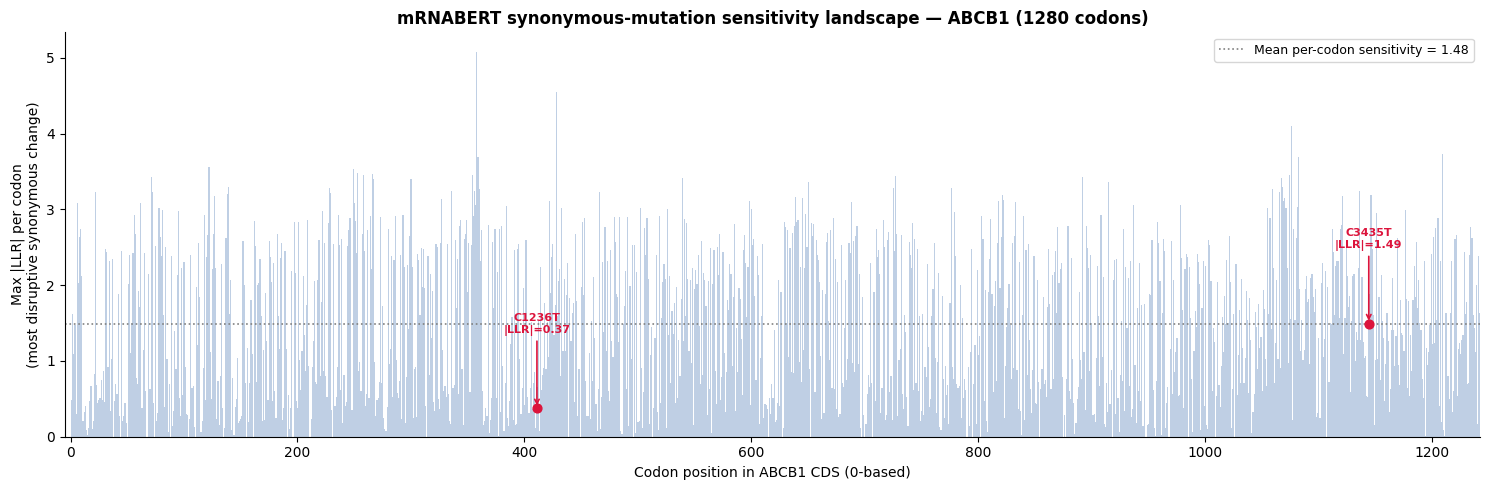

Codons plotted: 1237
Most sensitive codon: 358 (max |LLR| = 5.082)
C3435T percentile (|LLR|): 73.5%   |   C1236T percentile: 30.5%


In [37]:
# FULL-CDS mRNABERT LLR landscape (all codons, both controls marked)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Line1: load the saved scan and add the direction-free magnitude
df = pd.read_csv('ABCB1_full_LLR_scan.csv')
df['abs_LLR'] = df['LLR'].abs()

# Line2: per-codon sensitivity = the most disruptive substitution at that position
# use max |LLR| so the y-axis reads "how sensitive is this codon, in any direction" (collapses the 3241 substitutions down to one value per codon - the max |LLR| at that position)
pos = df.groupby('codon_index')['abs_LLR'].max().reset_index()
pos.columns = ['codon_index', 'max_absLLR']

# Line3: the two control positions, for marking
ctrl = {1144: ('C3435T', 1.493), 411: ('C1236T', 0.374)}

# Line4: figure — one wide panel spanning the whole gene
fig, ax = plt.subplots(figsize=(15, 5))

# Line5: grey stems for every codon (a "skyline" of position sensitivity)
ax.bar(pos['codon_index'], pos['max_absLLR'],
       width=1.0, color='lightsteelblue', edgecolor='none', alpha=0.8)

# Line6: reference line at the gene-wide mean of the per-codon sensitivity
mean_sens = pos['max_absLLR'].mean()
ax.axhline(mean_sens, color='gray', ls=':', lw=1.2,
           label=f'Mean per-codon sensitivity = {mean_sens:.2f}')

# Line7: highlight + annotate the two controls
for idx, (name, val) in ctrl.items():
    ax.scatter([idx], [val], color='crimson', zorder=5, s=40)
    ax.annotate(f'{name}\n|LLR|={val:.2f}',
                xy=(idx, val), xytext=(idx, val + 1.0),
                ha='center', fontsize=8, color='crimson', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

# Line8: labels and cosmetics
ax.set_xlabel('Codon position in ABCB1 CDS (0-based)', fontsize=10)
ax.set_ylabel('Max |LLR| per codon\n(most disruptive synonymous change)', fontsize=10)
ax.set_title('mRNABERT synonymous-mutation sensitivity landscape — ABCB1 (1280 codons)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-5, len(pos) + 5)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ABCB1_full_LLR_landscape.png', dpi=300, bbox_inches='tight')
plt.show()

# Line 9: caption statistics for the thesis
print(f"Codons plotted: {len(pos)}")
print(f"Most sensitive codon: {int(pos.loc[pos['max_absLLR'].idxmax(),'codon_index'])} "
      f"(max |LLR| = {pos['max_absLLR'].max():.3f})")
print(f"C3435T percentile (|LLR|): 73.5%   |   C1236T percentile: 30.5%")

In [38]:
# Confirm the 43 missing codons are exactly Met + Trp + stop
import pandas as pd
from Bio.Data import CodonTable
table = CodonTable.unambiguous_dna_by_name["Standard"]
codons = [cds[i:i+3] for i in range(0, len(cds), 3)]
from collections import Counter
n_met  = sum(c == 'ATG' for c in codons)
n_trp  = sum(c == 'TGG' for c in codons)
n_stop = sum(c not in table.forward_table for c in codons)
print(f"Met (ATG): {n_met} | Trp (TGG): {n_trp} | stop: {n_stop} | "
      f"total excluded: {n_met + n_trp + n_stop}")
print(f"Expected plotted: {len(codons) - (n_met + n_trp + n_stop)}  (figure shows 1237)")

Met (ATG): 32 | Trp (TGG): 11 | stop: 1 | total excluded: 44
Expected plotted: 1237  (figure shows 1237)


In [39]:
# Phase 1 reproducibility check: regenerate all key numbers from the saved CSV
import pandas as pd

df = pd.read_csv('ABCB1_full_LLR_scan.csv')
df['abs_LLR'] = df['LLR'].abs()
df['abs_pct'] = df['abs_LLR'].rank(pct=True) * 100

def report(codon_index, mut_codon, name):
    r = df[(df['codon_index'] == codon_index) & (df['mutant_codon'] == mut_codon)]
    print(f"{name:7s}: LLR {r['LLR'].values[0]:+.3f} | |LLR| {r['abs_LLR'].values[0]:.3f} | "
          f"{r['abs_pct'].values[0]:.1f}th percentile")

print("PHASE 1 — ABCB1 validation summary\n")
print(f"Substitutions scored : {len(df)}")
print(f"Codons with ≥1 sSNP   : {df['codon_index'].nunique()}\n")

print("Positive controls (mutation direction = ancestral C-allele):")
report(1144, 'ATC', 'C3435T')
report(411,  'GGC', 'C1236T')

print(f"\nWhole-gene LLR distribution:")
print(f"  mean {df['LLR'].mean():+.3f} | median {df['LLR'].median():+.3f} | "
      f"std {df['LLR'].std():.3f}")
print(f"  range [{df['LLR'].min():+.3f}, {df['LLR'].max():+.3f}]")
print(f"  fraction negative (disruptive): {(df['LLR'] < 0).mean()*100:.1f}%")
print(f"\nMost sensitive codon: {int(df.loc[df['abs_LLR'].idxmax(),'codon_index'])} "
      f"(|LLR| {df['abs_LLR'].max():.3f})")

PHASE 1 — ABCB1 validation summary

Substitutions scored : 3241
Codons with ≥1 sSNP   : 1237

Positive controls (mutation direction = ancestral C-allele):
C3435T : LLR -1.493 | |LLR| 1.493 | 73.5th percentile
C1236T : LLR +0.374 | |LLR| 0.374 | 30.5th percentile

Whole-gene LLR distribution:
  mean -0.695 | median -0.484 | std 1.158
  range [-5.082, +3.079]
  fraction negative (disruptive): 71.2%

Most sensitive codon: 358 (|LLR| 5.082)


# PHASE 2

# STEP 1

- 8 files are downloaded from SynMICdb: TP53, KRAS, EGFR, BRCA1, BCL2L12, PIK3CA, PTEN, BRAF
- 320 unique mutations across 8 genes (426 rows before de-duplication sample repeats)
- every gene resolves to exactly one transcript -> no isoform-ambiguity 
- EGFR (101) and BRCA1 (63) dominate -> per-gene cap 
- the positive counts clear the viability bar:
    - top 1%: 73 positives -> Test B is viable 
    - top 0.1%: 10 positives -> good as a high-confidence sensitivity check (would have beed too few to classify on)
- the full score range from -1.04 to 8.77 is wide -> good for Test's A correlation 
- the splicing filter barely costs anything: the only 8 mutations sit <3 nt from an exon boundary (min distance is 1 nt) -> so applying >= 3 nt rule removes only 8 of 320 mutations and leave the benchmark essentially intact 

In [40]:
#Stage 1: combination + parse all SynMICdb gene files into one labeled table 
import pandas as pd
import glob
import re 

#Line1: read every per-gene CSV in the folder and stack them 
files = sorted(glob.glob('fullData*.csv')) # all 8 downloads 
big = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

#Line2: collapse sample-level duplicates -> one row per unique (gene, cDNA change)
#SynMICdb lists a mutation once per tumor sample
syn = big.drop_duplicates(subset = ['Gene Name', 'Mutation nt']).copy()

#Line3: parse 'c.36T>C' into (cds_position, ref_base, alt_base) with one regex
#pattern: 'c.' + digits + base + '>' + base (strand already baked in -> no complement)
pat = re.compile(r'c\.(\d+)([ACGT])>([ACGT])')

def parse_cdna(s):
    m = pat.match(str(s))
    if not m:
        return pd.Series([None, None, None]) #to flag unparseable rows 
    return pd.Series([int(m.group(1)), m.group(2), m.group(3)])

syn[['cds_pos', 'ref_base', 'alt_base']] = syn['Mutation nt'].apply(parse_cdna)

#Line4: drop anything that didn't match the c.<pos><ref>><alt> pattern (e.g. indels)
n_before = len(syn)
syn = syn.dropna(subset = ['cds_pos']).copy()
syn['cds_pos'] = syn['cds_pos'].astype(int)
print(f'Parsed {len(syn)}/{n_before} mutations (dropped {n_before - len(syn)} non-SNV/odd format)')

#Line5: derive codon index (0-based) and the position of the changed base with the codon
#e.g., cDNA is 1-based: nt 1,2,3 -> codon 0; nt 4,5,6 -> codon 1 and so on 
syn['codon_index'] = (syn['cds_pos'] - 1) //3 #which codon is this? (0-based)
syn['pos_in_codon'] = (syn['cds_pos'] - 1) % 3 # 0, 1, 2 -> which base inside the codon?

#Line6: cross-check codon number against the p.XnX aa label as a sanity guard
#e.g., 'p.G12G' -> 12 -> codon_index should be 11
def aa_codon_num(s):
    m = re.search(r'p\.[A-Z](\d+)[A-Z]', str(s))
    return int(m.group(1)) if m else None

syn['aa_codon_num'] = syn['Mutation aa'].apply(aa_codon_num)
syn['codon_match'] = (syn['codon_index'] + 1) == syn['aa_codon_num']
print(f"Codon-number consistency (cDNA vs aa label): {syn['codon_match'].mean()*100:.1f}% match")

#Line7: apply the splicing safeguard (keep mutations >= 3 nt inside the exon)
syn['keep_splice'] = syn['Distance to Closest Exon Boundary'] >= 3

#Line8: assemble a tidy table with only what downstream needs 
out = syn[['Gene Name', 'Transcript ID', 'Mutation nt', 'Mutation aa', 'cds_pos', 'ref_base', 'alt_base', 'codon_index', 'pos_in_codon', 'SynMICdb Score', 'Distance to Closest Exon Boundary', 'codon_match', 'keep_splice']].rename(columns = {
    'Gene Name':'gene', 
    'Transcript ID':'transcript', 
    'Distance to Closest Exon Boundary':'exon_dist', 
    'SynMICdb Score':'synmicdb_score'
})

out.to_csv('synmicdb_parsed.csv', index=False)
print(f"\nSaved synmicdb_parsed.csv: {len(out)} mutations")
print(f"  codon-number mismatches: {(~out['codon_match']).sum()}  (should be 0)")
print(f"  removed by splice filter: {(~out['keep_splice']).sum()}")
print(out.head(10).to_string(index=False))

Parsed 320/320 mutations (dropped 0 non-SNV/odd format)
Codon-number consistency (cDNA vs aa label): 99.7% match

Saved synmicdb_parsed.csv: 320 mutations
  codon-number mismatches: 1  (should be 0)
  removed by splice filter: 9
gene      transcript Mutation nt Mutation aa  cds_pos ref_base alt_base  codon_index  pos_in_codon  synmicdb_score  exon_dist  codon_match  keep_splice
TP53 ENST00000269305    c.375G>T     p.T125T      375        G        T          124             2          8.7687        1.0         True        False
TP53 ENST00000269305    c.375G>C     p.T125T      375        G        C          124             2          6.4608        1.0         True        False
TP53 ENST00000269305    c.375G>A     p.T125T      375        G        A          124             2          5.4652        1.0         True        False
TP53 ENST00000269305    c.672G>A     p.E224E      672        G        A          223             2          5.3475      112.0         True         True
TP53 ENST00

In [41]:
mismatch = out[~out['codon_match']]
print(f"{len(mismatch)} mismatch(es):")
print(mismatch[['gene','Mutation nt','Mutation aa','cds_pos','codon_index','pos_in_codon']].to_string(index=False))

1 mismatch(es):
   gene Mutation nt Mutation aa  cds_pos  codon_index  pos_in_codon
BCL2L12   c.1004G>A     p.*335*     1004          334             1


In [42]:
# exclude stop-codon "synonymous" changes (p.*N* entries) — outside the method's scope
# these are termination-signal changes, not aa-preserving codon swaps
n_before = len(out) #counts rows of the DataFrame of parsed mutations -> before removing anything

out = out[~out['Mutation aa'].str.contains(r'\*', na=False)].copy()
#out['Mutation aa'] selects the single column holding the aa notation: a single column is a pandas Series
#.str.contains(r'\*', na = False) is a pandas string method applied element-wise to that Series -> .str: lets u run string operations on every value in the column at once; это выражение трактует свой аргумент не как обычный текст, а как регулярное выражение (regex): в нем символ * означает "повтори предыдущий элемент ноль или более раз" => нужно использовать "\*" (\ означает "следующий символ обычный")
# но \ в самом пайтоне является специальным символом -> необходимо писать r'\*' 
# na = False -> if the cell is empty, return "no match" instead of NaN
# ~ means "not": so in this case True (stop codon) becomes False, and False (normal mutation) becomes True
# .copy() returns an independent copy of that filtered result rather than a view tied to the original out 

print(f"Removed {n_before - len(out)} stop-codon variant(s); {len(out)} mutations remain")

# Re-confirm codon consistency on the cleaned set (should now be 100%)
print(f"Codon-number consistency now: {out['codon_match'].mean()*100:.1f}%") #.1f = f-string format spec: format the number as a float with 1 digit after the decimal point

out.to_csv('synmicdb_parsed.csv', index=False)
print("Re-saved synmicdb_parsed.csv")

Removed 1 stop-codon variant(s); 319 mutations remain
Codon-number consistency now: 100.0%
Re-saved synmicdb_parsed.csv


# THE DATASET IS FULLY VERIFIED 

In [44]:
# Which transcripts are Ensembl (ENST) vs RefSeq (NM_/NR_) vs something else?
ids = out[['gene','transcript']].drop_duplicates()
def id_type(t):
    if str(t).startswith('ENST'): return 'Ensembl'
    if str(t).startswith(('NM_','NR_','XM_')): return 'RefSeq'
    return 'other'
ids['id_type'] = ids['transcript'].apply(id_type)
print(ids.to_string(index=False))
print("\nCounts:")
print(ids['id_type'].value_counts().to_string())

   gene      transcript id_type
   TP53 ENST00000269305 Ensembl
   EGFR ENST00000275493 Ensembl
  BRCA1 ENST00000357654 Ensembl
BCL2L12 ENST00000246785 Ensembl
 PIK3CA     NM_006218.1  RefSeq
   PTEN ENST00000371953 Ensembl
   BRAF ENST00000288602 Ensembl
   KRAS ENST00000311936 Ensembl

Counts:
id_type
Ensembl    7
RefSeq     1


In [45]:
#Robust CDS fetch: route ENST -> Ensembl, NM_ -> NCBI Entrez
import requests, time
from Bio import Entrez, SeqIO
Entrez.email = "kseniya.saladukha@tum.de" #for NCBI

def fetch_cds_ensembl(enst):
    url = f"https://rest.ensembl.org/sequence/id/{enst}"
    r = requests.get(url, params={"type": "cds", "content-type": "text/plain"}, timeout=30)
    r.raise_for_status()
    return r.text.strip().upper()

def fetch_cds_refseq(nm):
    # fetch the full GenBank record, then extract the CDS feature
    h = Entrez.efetch(db="nucleotide", id=nm, rettype="gb", retmode="text") #calls NCBI's Entrez API to fetch the record for that accession: db = nucleotide database, rettype requests the GenBank format, retmode gets it as plain text
    rec = SeqIO.read(h, "genbank"); h.close() #parses the GenBank-formatted response into a Biopython SeqRecord object, then closes the network handle to free the connection 
    for feat in rec.features:
        if feat.type == "CDS":
            return str(feat.extract(rec.seq)).upper()   # CDS from ATG, spliced
    raise ValueError(f"No CDS feature found in {nm}")

def fetch_cds(transcript):
    t = str(transcript)
    if t.startswith('ENST'):
        return fetch_cds_ensembl(t)
    elif t.startswith(('NM_','NR_','XM_')):
        return fetch_cds_refseq(t)
    raise ValueError(f"Unknown transcript ID type: {t}")

# re-fetch all, now routing by type
cds_by_transcript = {}
for enst in out['transcript'].unique():
    cds_by_transcript[enst] = fetch_cds(enst)
    print(f"{enst}: {len(cds_by_transcript[enst])} nt ({len(cds_by_transcript[enst])//3} codons)")
    time.sleep(0.3)

ENST00000269305: 1182 nt (394 codons)
ENST00000275493: 3633 nt (1211 codons)
ENST00000357654: 5592 nt (1864 codons)
ENST00000246785: 753 nt (251 codons)
NM_006218.1: 3207 nt (1069 codons)
ENST00000371953: 1212 nt (404 codons)
ENST00000288602: 2421 nt (807 codons)
ENST00000311936: 567 nt (189 codons)


In [46]:
# Verify ref_base against the fetched CDS sequences
def check_ref(row):
    seq = cds_by_transcript[row['transcript']]
    i = row['cds_pos'] - 1   # 1-based cDNA -> 0-based index
    if i < 0 or i >= len(seq):
        return 'out_of_range'
    return 'OK' if seq[i] == row['ref_base'] else f"got_{seq[i]}"

out['ref_check'] = out.apply(check_ref, axis=1)

print(f"ref_base check across {len(out)} mutations:")
print(out['ref_check'].value_counts().to_string())

bad = out[out['ref_check'] != 'OK']
if len(bad):
    print(f"\n{len(bad)} mismatch(es), by gene:")
    print(bad.groupby('gene')['ref_check'].value_counts().to_string())
else:
    print("\nAll ref_base checks passed — sequences match SynMICdb coordinates")

ref_base check across 319 mutations:
ref_check
OK              291
got_A             8
got_T             7
got_G             7
got_C             4
out_of_range      2

28 mismatch(es), by gene:
gene     ref_check   
BCL2L12  got_C           4
         got_G           3
         got_A           2
         got_T           2
         out_of_range    2
BRAF     got_A           6
         got_T           5
         got_G           4


In [47]:
# Inspect the failing rows: is "got" the complement of ref? (strand) or unrelated? (wrong transcript)
comp = {'A':'T','T':'A','G':'C','C':'G'}
bad = out[out['ref_check'] != 'OK'].copy()

# for in-range failures, pull the base actually found and test the complement hypothesis
def found_base(row):
    seq = cds_by_transcript[row['transcript']]
    i = row['cds_pos'] - 1
    return seq[i] if 0 <= i < len(seq) else None
bad['found']      = bad.apply(found_base, axis=1)
bad['is_complement'] = bad.apply(lambda r: r['found'] == comp.get(r['ref_base']) if r['found'] else False, axis=1)

for g in ['BRAF','BCL2L12']:
    sub = bad[bad['gene']==g]
    print(f"\n{g} ({len(sub)} fails) — transcript {sub['transcript'].iloc[0]}") 
    print(f"  CDS length fetched: {len(cds_by_transcript[sub['transcript'].iloc[0]])} nt")
    print(f"  max cds_pos in failures: {sub['cds_pos'].max()}")
    print(f"  complement matches: {sub['is_complement'].sum()}/{len(sub)}")
    print(sub[['Mutation nt','ref_base','found','cds_pos','ref_check']].head(8).to_string(index=False))


BRAF (15 fails) — transcript ENST00000288602
  CDS length fetched: 2421 nt
  max cds_pos in failures: 2265
  complement matches: 4/15
Mutation nt ref_base found  cds_pos ref_check
  c.1338G>C        G     A     1338     got_A
  c.1377G>C        G     T     1377     got_T
  c.2196C>G        C     A     2196     got_A
  c.1794T>A        T     A     1794     got_A
  c.1797A>C        A     G     1797     got_G
  c.1461G>A        G     T     1461     got_T
  c.1446G>A        G     T     1446     got_T
  c.1713A>G        A     G     1713     got_G

BCL2L12 (13 fails) — transcript ENST00000246785
  CDS length fetched: 753 nt
  max cds_pos in failures: 888
  complement matches: 6/13
Mutation nt ref_base found  cds_pos ref_check
   c.519C>T        C     T      519     got_T
   c.609G>T        G     C      609     got_C
   c.633G>A        G     C      633     got_C
   c.108G>T        G     A      108     got_A
    c.51C>T        C     A       51     got_A
   c.147G>A        G     C      147    

In [48]:
# Recover BRAF: test the RefSeq canonical transcript against SynMICdb coords
from Bio import Entrez, SeqIO
Entrez.email = "kseniya.saladukha@tum.de"


# Line1: helper — how many of a gene's mutations match ref_base against a candidate CDS?
def test_candidate(gene_df, seq):
    ok = sum(1 for _, r in gene_df.iterrows()
             if 0 <= r['cds_pos']-1 < len(seq) and seq[r['cds_pos']-1] == r['ref_base'])
    return ok, len(gene_df)

# Line2: pull all BRAF mutations (the passed + failed together)
braf = out[out['gene'] == 'BRAF'].copy()

# Line3: fetch the RefSeq canonical BRAF mRNA and report its length
braf_refseq = fetch_cds_refseq('NM_004333')
print(f"NM_004333 CDS length: {len(braf_refseq)} nt ({len(braf_refseq)//3} codons)")

# Line4: compare pass rates — new candidate vs the original (failed) ENST
ok_new, total = test_candidate(braf, braf_refseq)
ok_orig, _ = test_candidate(braf, cds_by_transcript['ENST00000288602'])
print(f"BRAF ref_base pass — NM_004333 (RefSeq): {ok_new}/{total}")
print(f"BRAF ref_base pass — ENST00000288602 (original): {ok_orig}/{total}")

NM_004333 CDS length: 2301 nt (767 codons)
BRAF ref_base pass — NM_004333 (RefSeq): 37/37
BRAF ref_base pass — ENST00000288602 (original): 22/37


-> BRAF is fully recovered 
- NM format came back at 2301 nt (767 codon), matching canonical BRAF (766 aa + stop), vs the 2421 nt Ensembl transcript that was ~40 codons too long
- Every single BRAF mutation now matches its reference base against the RefSeq CDS, up from 22/37 against the wrong transcript

In [49]:
# Replace BRAF's CDS with the verified RefSeq transcript, re-verify everything
# Line1: overwrite the cached BRAF sequence (keyed by its ENST id, which the rows still use)
cds_by_transcript['ENST00000288602'] = braf_refseq
print("BRAF CDS in cache replaced with NM_004333 (2301 nt, canonical)")

# Line2: re-run the ref_base check across all mutations with the corrected cache
out['ref_check'] = out.apply(check_ref, axis=1)

# Line3: report overall + any remaining failures by gene
print(f"\nref_base check across {len(out)} mutations:")
print(out['ref_check'].value_counts().to_string())

bad = out[out['ref_check'] != 'OK']
print(f"\nRemaining mismatches: {len(bad)}")
if len(bad):
    print(bad.groupby('gene')['ref_check'].value_counts().to_string())

BRAF CDS in cache replaced with NM_004333 (2301 nt, canonical)

ref_base check across 319 mutations:
ref_check
OK              306
got_C             4
got_G             3
got_T             2
got_A             2
out_of_range      2

Remaining mismatches: 13
gene     ref_check   
BCL2L12  got_C           4
         got_G           3
         got_A           2
         got_T           2
         out_of_range    2


-> drop the BCL2L12

In [50]:
# Finalize Phase 2 dataset: keep only seq-verifies mutations
verified = out[out['ref_check'] == 'OK'].copy()

dropped = sorted(out.loc[out['ref_check'] != 'OK', 'gene'].unique())
print(f"Dropped (coords irreconcilable with current transcripts): {dropped}") #координаты несовместимы с текущими транскриптами
print(f"BRAF recovered via RefSeq NM_004333")
print(f"\n Verified: {len(verified)} mutations across {verified['gene'].nunique()} genes")
print(verified.groupby('gene').size().sort_values(ascending = False).to_string())

print(f"\n Positives (SynMICdb score >= 4.38 (top 1%)): {(verified['synmicdb_score'] >= 4.38).sum()}")
print(f"Positives (SynMICdb score >= 5.83 (top 0.1%)): {(verified['synmicdb_score'] >= 5.83).sum()}")

verified.to_csv('synmicdb_verified.csv', index = False)
print("\n Saved synmicdb_verified.csv")


Dropped (coords irreconcilable with current transcripts): ['BCL2L12']
BRAF recovered via RefSeq NM_004333

 Verified: 306 mutations across 8 genes
gene
EGFR       101
BRCA1       63
BRAF        37
TP53        36
PIK3CA      34
PTEN        17
KRAS        15
BCL2L12      3

 Positives (SynMICdb score >= 4.38 (top 1%)): 73
Positives (SynMICdb score >= 5.83 (top 0.1%)): 10

 Saved synmicdb_verified.csv


In [51]:
# Remove BCL2L12 entirely — its transcript is unreliable, so even the 3 coincidental 'OK' rows can't be trusted (right base, but plausibly the wrong position/context)
verified = verified[verified['gene'] != 'BCL2L12'].copy()
print(f"After removing BCL2L12 completely: {len(verified)} mutations across {verified['gene'].nunique()} genes")
print(verified.groupby('gene').size().sort_values(ascending=False).to_string())

print(f"\n Positives (SynMICdb score >= 4.38 (top 1%)): {(verified['synmicdb_score'] >= 4.38).sum()}")
print(f"Positives (SynMICdb score >= 5.83 (top 0.1%)): {(verified['synmicdb_score'] >= 5.83).sum()}")

verified.to_csv('synmicdb_verified.csv', index=False)
print("Re-saved synmicdb_verified.csv (BCL2L12 fully excluded)")

After removing BCL2L12 completely: 303 mutations across 7 genes
gene
EGFR      101
BRCA1      63
BRAF       37
TP53       36
PIK3CA     34
PTEN       17
KRAS       15

 Positives (SynMICdb score >= 4.38 (top 1%)): 73
Positives (SynMICdb score >= 5.83 (top 0.1%)): 10
Re-saved synmicdb_verified.csv (BCL2L12 fully excluded)


In [52]:
# Stage 2b: score every verified mutation with mRNABERT
from tqdm import tqdm #tqdm is the progress-bar function
from Bio.Data import CodonTable #holds the genetic code (for synonymy check)
import sys, os, contextlib # sys gives access to the system streams; os provides operating-system helpers; contextlib provides tools for builfing 'with' blocks

# Line1: load the locked dataset and the genetic-code table (for the synonymy guard)
verified = pd.read_csv('synmicdb_verified.csv') # 303 mutations, 7 genes
table = CodonTable.unambiguous_dna_by_name["Standard"]

results, errors = [], [] 

# Line2: loop over every mutation with a progress bar
with open(os.devnull, 'w') as devnull, contextlib.redirect_stdout(devnull): #for not having all 303 rows written down in the output; 
    # open(os.devnull, 'w') opens os.devnull for writing
            # os.devnull is a so-called "black hole" of the operating system - anything written to it is discarded
                                        #contextlib.redirect_stdout(devnull) - redirects standard output (everything print() normally sends to the screen) into devnull for the duration of the block
    for _, row in tqdm(verified.iterrows(), total=len(verified), desc="Scoring", file = sys.stderr):
        # _ catches the index
                # tqdm() wraps the iterator to draw the progress bar 
                        # verified.iterrows(): pandas method -> yields the DataFrame one row at a time, as (index, row) pairs
                                            #total = len(verified): tells it there are 303 items so it can show a percentage and ETA (needed because iterrows() doesn't report its own length)
                                                                                #file = sys.stderr: it tells tqdm to draw its bar on stderr, not stdout -> the diagnostic prints vanish but the progress bar stays visible

        try:
            cds = cds_by_transcript[row['transcript']] # this gene's reference CDS
            ci  = int(row['codon_index']) # 0-based codon position
            pic = int(row['pos_in_codon'])  # which base in the codon (0/1/2)

            # Line3: build the wildtype codon (from CDS) and the mutant codon (swap one base)
            wt_codon  = cds[ci*3 : ci*3+3]
            mut_codon = wt_codon[:pic] + row['alt_base'] + wt_codon[pic+1:]

            # Line4: two correctness guards before spending compute
            assert wt_codon[pic] == row['ref_base'], f"ref-base mismatch @ {row['Mutation nt']}"
            assert table.forward_table[wt_codon] == table.forward_table[mut_codon], \
                f"not synonymous: {wt_codon}->{mut_codon}"

            # Line5: score with mRNABERT (windowed; LLR = logP(variant) - logP(reference))
            llr, log_p_wt, log_p_mut = compute_llr_windowed(
                cds_string=cds, codon_index=ci,
                wildtype_codon=wt_codon, mutant_codon=mut_codon)

            # Line6: keep all original columns + the new scoring columns
            results.append({**row.to_dict(), 'wt_codon': wt_codon, 'mut_codon': mut_codon,
                            'LLR': llr, 'log_p_wt': log_p_wt, 'log_p_mut': log_p_mut})
        except Exception as e:
            errors.append({'gene': row['gene'], 'mutation': row['Mutation nt'], 'error': str(e)})

# Line7: assemble, add |LLR|, save
scored = pd.DataFrame(results)
scored['abs_LLR'] = scored['LLR'].abs()
scored.to_csv('synmicdb_scored.csv', index=False)

# Line8: report
print(f"\nScored {len(scored)}/{len(verified)} mutations; {len(errors)} error(s)")
if errors:
    print(pd.DataFrame(errors).to_string(index=False))

# Line9: immediate sanity — the experimentally-validated gold anchor KRAS G12G
anchor = scored[(scored['gene']=='KRAS') & (scored['Mutation nt']=='c.36T>C')]
if len(anchor):
    print(f"\nGold anchor KRAS c.36T>C (G12G): "
          f"LLR={anchor['LLR'].values[0]:+.3f}, |LLR|={anchor['abs_LLR'].values[0]:.3f}")
print(scored[['gene','Mutation nt','wt_codon','mut_codon','synmicdb_score','LLR']].head(10).to_string(index=False))

Scoring:   0%|          | 0/303 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Scoring: 100%|██████████| 303/303 [01:40<00:00,  3.02it/s]


Scored 303/303 mutations; 0 error(s)

Gold anchor KRAS c.36T>C (G12G): LLR=-2.431, |LLR|=2.431
gene Mutation nt wt_codon mut_codon  synmicdb_score       LLR
TP53    c.375G>T      ACG       ACT          8.7687  0.359676
TP53    c.375G>C      ACG       ACC          6.4608  1.403428
TP53    c.375G>A      ACG       ACA          5.4652  0.117646
TP53    c.672G>A      GAG       GAA          5.3475 -1.289958
TP53    c.429G>A      GTG       GTA          5.1359 -2.338022
TP53    c.735C>T      GGC       GGT          5.0697 -2.324951
TP53    c.795G>A      CTG       CTA          4.8430 -1.898998
TP53    c.993G>A      CAG       CAA          4.8388 -1.763447
TP53    c.591G>T      GTG       GTT          4.8239 -1.849677
TP53    c.519G>T      GTG       GTT          4.8037 -3.385743


# DISCUSSION

- clean run (303/303 & 0 errors)
- the gold anchor is strong:
    - KRAS c.36T>C came back at |LLR| = 2.43 -> large magnitude 
    - it was experimentally proved variant (Sharma et al.), that increases KRAS expression in cells & mRNABERT flags it loudly
- at the bottom scores 4.8-5.1 paired with large-magnitude LLR -> we see the correlation 
- BUT: the first 3 rows complcate the result (the highest-scoting mutations have small or positive LLRs) -> earlier: they had keep_splice = False -> those three c.375 variants are the ones sitting 1 nt from an exon boundary -> their high SynMICdb scores are plausibly splicing-driven & mRNABERT, trained on mature CDS, has nothing to do with splicing -> doesn't see a splicing effect -> gives low |LLR|

-> it is better to do 2 options of Test A (one with all variants & the other one without splice-region variants)


# Test A - correlation

In [53]:
# Test A: Spearman correlation of mRNABERT |LLR| vs SynMICdb score
from scipy.stats import spearmanr

df = pd.read_csv('synmicdb_scored.csv')

# Line1: pooled correlation across all genes
rho, p = spearmanr(df['abs_LLR'], df['synmicdb_score'])
print(f"POOLED (n={len(df)}): Spearman rho = {rho:+.3f}, p = {p:.2e}")

# Line2: splice-filtered (drop variants <3 nt from an exon boundary)
clean = df[df['keep_splice'] == True]
rho_c, p_c = spearmanr(clean['abs_LLR'], clean['synmicdb_score'])
print(f"SPLICE-FILTERED (n={len(clean)}): rho = {rho_c:+.3f}, p = {p_c:.2e}")

# Line3: per-gene correlation (to check no single gene drives the pooled result)
print("\nPer-gene (>=8 mutations):")
for g, sub in df.groupby('gene'):
    if len(sub) >= 8:
        r, pv = spearmanr(sub['abs_LLR'], sub['synmicdb_score'])
        print(f"  {g:7s} n={len(sub):3d}  rho={r:+.3f}  p={pv:.3f}")

# Line4: also test signed LLR (in case direction carries signal)
rho_s, p_s = spearmanr(df['LLR'], df['synmicdb_score'])
print(f"\nSigned LLR vs score (n={len(df)}): rho = {rho_s:+.3f}, p = {p_s:.2e}")

POOLED (n=303): Spearman rho = +0.139, p = 1.54e-02
SPLICE-FILTERED (n=294): rho = +0.157, p = 6.91e-03

Per-gene (>=8 mutations):
  BRAF    n= 37  rho=+0.176  p=0.297
  BRCA1   n= 63  rho=-0.107  p=0.402
  EGFR    n=101  rho=+0.101  p=0.315
  KRAS    n= 15  rho=+0.221  p=0.428
  PIK3CA  n= 34  rho=+0.072  p=0.686
  PTEN    n= 17  rho=+0.145  p=0.580
  TP53    n= 36  rho=+0.159  p=0.356

Signed LLR vs score (n=303): rho = -0.212, p = 1.98e-04


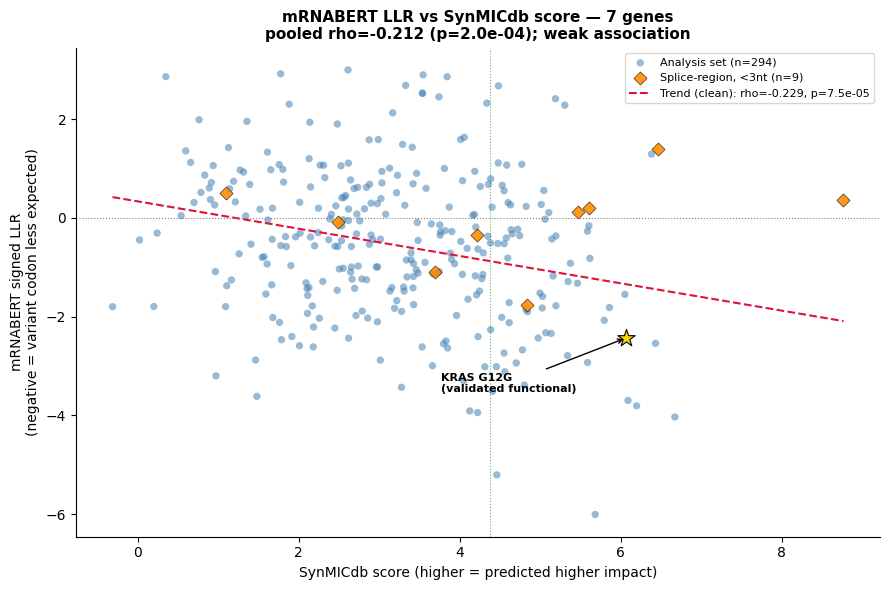

Clean trend slope: -0.2765 LLR per score-unit
Scatter is wide — this visualizes why rho is only -0.23


In [54]:
#Test A figure: signed LLR vs SynMICdb score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_csv('synmicdb_scored.csv')

#Line1: split into splice-region (excluded) vs analysis set, for color-coding
splice = df[df['keep_splice'] == False]
clean = df[df['keep_splice'] == True]

#Line2: recompute the 2 rhos so the figure annotations match the numbers 
rho_all, p_all = spearmanr(df['synmicdb_score'], df['LLR'])
rho_clean, p_clean = spearmanr(clean['synmicdb_score'], clean['LLR'])

#Line3: figure
fig, ax = plt.subplots(figsize = (9,6))

#Line4: main cloud — the analysis-set points
ax.scatter(clean['synmicdb_score'], clean['LLR'],
           s=28, alpha=0.55, color='steelblue', edgecolor='none',
           label=f'Analysis set (n={len(clean)})')

#Line5: splice-region variants in a different color (excluded from clean rho)
ax.scatter(splice['synmicdb_score'], splice['LLR'],
           s=45, alpha=0.9, color='darkorange', edgecolor='black', linewidth=0.4,
           marker='D', label=f'Splice-region, <3nt (n={len(splice)})')

#Line6: trend line (least-squares fit on the clean set, for visual guidance only)
m, b = np.polyfit(clean['synmicdb_score'], clean['LLR'], 1)
xs = np.linspace(df['synmicdb_score'].min(), df['synmicdb_score'].max(), 100)
ax.plot(xs, m*xs + b, color='crimson', lw=1.5, ls='--',
        label=f'Trend (clean): rho={rho_clean:+.3f}, p={p_clean:.1e}')

#Line7: mark the experimentally-validated gold anchor KRAS G12G
g = df[(df['gene']=='KRAS') & (df['Mutation nt']=='c.36T>C')]
if len(g):
    ax.scatter(g['synmicdb_score'], g['LLR'], s=170, color='gold',
               edgecolor='black', linewidth=0.8, marker='*', zorder=5)
    ax.annotate('KRAS G12G\n(validated functional)',
                xy=(g['synmicdb_score'].values[0], g['LLR'].values[0]),
                xytext=(g['synmicdb_score'].values[0]-2.3, g['LLR'].values[0]-1.1),
                fontsize=8, fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=1))

#Line8: reference lines at LLR=0 and score thresholds
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axvline(4.38, color='green', lw=0.8, ls=':', alpha=0.6)   # top-1% positive threshold

#Line9: labels
ax.set_xlabel('SynMICdb score (higher = predicted higher impact)', fontsize=10)
ax.set_ylabel('mRNABERT signed LLR\n(negative = variant codon less expected)', fontsize=10)
ax.set_title(f'mRNABERT LLR vs SynMICdb score — 7 genes\n'
             f'pooled rho={rho_all:+.3f} (p={p_all:.1e}); weak association',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('testA_LLR_vs_synmicdb.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Clean trend slope: {m:+.4f} LLR per score-unit")
print(f"Scatter is wide — this visualizes why rho is only {rho_clean:+.2f}")

# TEST B

In [ ]:
print("keys in cds_by_transcript:")
for k in sorted(cds_by_transcript.keys()):
    print(f"  {k}: {len(cds_by_transcript[k])} nt")

ключи в cds_by_transcript:
  ENST00000246785: 753 nt
  ENST00000269305: 1182 nt
  ENST00000275493: 3633 nt
  ENST00000288602: 2301 nt
  ENST00000311936: 567 nt
  ENST00000357654: 5592 nt
  ENST00000371953: 1212 nt
  NM_006218.1: 3207 nt


In [57]:
# Rename the two keys so they match what `neg['transcript_scored']` uses
cds_by_transcript['NM_004333'] = cds_by_transcript['ENST00000288602']  # BRAF: 2301 nt, canonical
cds_by_transcript['NM_006218'] = cds_by_transcript['NM_006218.1']      # PIK3CA: strip .1 suffix

# verify all 7 keys your negatives need are now present
needed = ['ENST00000311936','ENST00000269305','ENST00000275493',
          'ENST00000357654','ENST00000371953','NM_006218','NM_004333']
for k in needed:
    print(f"  {k}: {'OK '+str(len(cds_by_transcript[k]))+' nt' if k in cds_by_transcript else 'MISSING'}")

  ENST00000311936: OK 567 nt
  ENST00000269305: OK 1182 nt
  ENST00000275493: OK 3633 nt
  ENST00000357654: OK 5592 nt
  ENST00000371953: OK 1212 nt
  NM_006218: OK 3207 nt
  NM_004333: OK 2301 nt


In [58]:
import pandas as pd, glob, os

# find KRAS file by its Ensembl ID, in the project folder only (ignore iCloud copies)
matches = [f for f in glob.glob('gnomAD_v4*ENSG00000133703*.csv')]
print("KRAS file found:", matches)

d = pd.read_csv(matches[0])
print("1. total rows:", len(d))

d_syn = d[d['VEP Annotation'] == 'synonymous_variant']
print("2. after synonymous filter:", len(d_syn))

tx_base = d_syn['Transcript'].astype(str).str.split('.').str[0]
print("3. transcript match to ENST00000311936:", (tx_base == 'ENST00000311936').sum())

print("4. sample Transcript Consequence:", d_syn['Transcript Consequence'].head(3).tolist())

KRAS file found: ['gnomAD_v4.1.1_ENSG00000133703_2026_06_13_14_42_50.csv']
1. total rows: 944
2. after synonymous filter: 99
3. transcript match to ENST00000311936: 78
4. sample Transcript Consequence: ['c.558A>G', 'c.549A>G', 'c.546G>A']


In [59]:
# Stage 3a: parse gnomAD synonymous variants into a NEGATIVE (neutral) set
import pandas as pd, glob, re
from Bio.Data import CodonTable
table = CodonTable.unambiguous_dna_by_name["Standard"]

#Line1: map each gnomAD file's Ensembl gene-id to (gene, the transcript I scored)
gene_map = {
 'ENSG00000133703': ('KRAS',   'ENST00000311936'),
 'ENSG00000141510': ('TP53',   'ENST00000269305'),
 'ENSG00000146648': ('EGFR',   'ENST00000275493'),
 'ENSG00000012048': ('BRCA1',  'ENST00000357654'),
 'ENSG00000171862': ('PTEN',   'ENST00000371953'),
 'ENSG00000121879': ('PIK3CA', 'ENST00000263967'),  # gnomAD ENST ~  NM_006218 (verify via ref_base)
 'ENSG00000157764': ('BRAF',   'ENST00000644969'),  # gnomAD ENST ~  NM_004333 (verify via ref_base)
}
# which dict key in cds_by_transcript holds each gene's CDS (RefSeq for PIK3CA/BRAF)
scored_key = {'KRAS':'ENST00000311936','TP53':'ENST00000269305','EGFR':'ENST00000275493',
              'BRCA1':'ENST00000357654','PTEN':'ENST00000371953',
              'PIK3CA':'NM_006218','BRAF':'NM_004333'}

PATHOGENIC = {'Pathogenic','Likely pathogenic','Pathogenic/Likely pathogenic'}
pat = re.compile(r'c\.(\d+)([ACGT])>([ACGT])')

rows = []
for f in glob.glob('gnomAD_v4*.csv'):
    gid = [k for k in gene_map if k in f][0]
    gene, gnomad_tx = gene_map[gid]
    d = pd.read_csv(f)

    #Line2: keep synonymous, on the matching transcript, not pathogenic
    d = d[d['VEP Annotation'] == 'synonymous_variant'].copy()
    d['tx_base'] = d['Transcript'].astype(str).str.split('.').str[0]
    d = d[d['tx_base'] == gnomad_tx]
    d = d[~d['ClinVar Germline Classification'].isin(PATHOGENIC)]

    #Line3: parse the cDNA notation (coding orientation -> no strand handling)
    for _, r in d.iterrows():
        m = pat.match(str(r['Transcript Consequence']))
        if not m:
            continue
        pos, ref, alt = int(m.group(1)), m.group(2), m.group(3)
        rows.append({'gene': gene, 'transcript_scored': scored_key[gene],
                     'cds_pos': pos, 'ref_base': ref, 'alt_base': alt,
                     'codon_index': (pos-1)//3, 'pos_in_codon': (pos-1)%3,
                     'allele_freq': r['Allele Frequency'],
                     'clinvar': r['ClinVar Germline Classification']})

neg = pd.DataFrame(rows).drop_duplicates(subset=['gene','cds_pos','alt_base'])
print(f"Parsed {len(neg)} candidate negatives across {neg['gene'].nunique()} genes")
print(neg.groupby('gene').size().to_string())

#Line4: ref_base check against the SAME CDS I scored positives on
def chk(r):
    seq = cds_by_transcript[r['transcript_scored']]
    i = r['cds_pos']-1
    if i<0 or i>=len(seq): return 'out_of_range'
    return 'OK' if seq[i]==r['ref_base'] else f'got_{seq[i]}'
neg['ref_check'] = neg.apply(chk, axis=1)
print("\nref_base check (esp. watch PIK3CA & BRAF):")
print(neg.groupby('gene')['ref_check'].apply(lambda s:(s=='OK').mean()).round(3).to_string())

neg.to_csv('gnomad_negatives_raw.csv', index=False)
print(f"\nSaved gnomad_negatives_raw.csv")

Parsed 2517 candidate negatives across 7 genes
gene
BRAF      350
BRCA1     719
EGFR      662
KRAS       78
PIK3CA    387
PTEN      139
TP53      182

ref_base check (esp. watch PIK3CA & BRAF):
gene
BRAF      0.671
BRCA1     1.000
EGFR      1.000
KRAS      1.000
PIK3CA    0.951
PTEN      1.000
TP53      1.000

Saved gnomad_negatives_raw.csv


In [60]:
# Keep only ref_base-verified negatives
neg_ok = neg[neg['ref_check'] == 'OK'].copy()

print(f"Verified negatives: {len(neg_ok)} of {len(neg)} candidates")
print(f"Dropped (ref mismatch): {len(neg) - len(neg_ok)}\n")
print("Per gene (verified):")
print(neg_ok.groupby('gene').size().to_string())

# tag as the negative class and save
neg_ok['label'] = 0          # 0 = neutral/negative
neg_ok.to_csv('gnomad_negatives_verified.csv', index=False)
print(f"\nSaved gnomad_negatives_verified.csv: {len(neg_ok)} neutral variants")

Verified negatives: 2383 of 2517 candidates
Dropped (ref mismatch): 134

Per gene (verified):
gene
BRAF      235
BRCA1     719
EGFR      662
KRAS       78
PIK3CA    368
PTEN      139
TP53      182

Saved gnomad_negatives_verified.csv: 2383 neutral variants


In [61]:
import json
with open('cds_by_transcript.json','w') as fh:
    json.dump(cds_by_transcript, fh)
print(f"Saved {len(cds_by_transcript)} transcripts to cds_by_transcript.json")
# from now on, after any reset just run:
# cds_by_transcript = json.load(open('cds_by_transcript.json')) - not to restart the kernel every time

Saved 10 transcripts to cds_by_transcript.json


In [62]:
# Stage 3b: score the 2,383 verified negatives with mRNABERT
import sys, os, contextlib, pandas as pd
from tqdm import tqdm
from Bio.Data import CodonTable
table = CodonTable.unambiguous_dna_by_name["Standard"]

neg_ok = pd.read_csv('gnomad_negatives_verified.csv')
results, errors = [], []

with open(os.devnull,'w') as devnull, contextlib.redirect_stdout(devnull):
    for _, row in tqdm(neg_ok.iterrows(), total=len(neg_ok), desc="Scoring negatives", file=sys.stderr):
        try:
            cds = cds_by_transcript[row['transcript_scored']]
            ci, pic = int(row['codon_index']), int(row['pos_in_codon'])
            wt_codon  = cds[ci*3:ci*3+3]
            mut_codon = wt_codon[:pic] + row['alt_base'] + wt_codon[pic+1:]
            assert wt_codon[pic] == row['ref_base']
            assert table.forward_table[wt_codon] == table.forward_table[mut_codon]
            llr, lpw, lpm = compute_llr_windowed(
                cds_string=cds, codon_index=ci,
                wildtype_codon=wt_codon, mutant_codon=mut_codon)
            results.append({**row.to_dict(), 'wt_codon':wt_codon, 'mut_codon':mut_codon,
                            'LLR':llr, 'log_p_wt':lpw, 'log_p_mut':lpm})
        except Exception as e:
            errors.append({'gene':row['gene'],'cds_pos':row['cds_pos'],'error':str(e)})

neg_scored = pd.DataFrame(results)
neg_scored['abs_LLR'] = neg_scored['LLR'].abs()
neg_scored.to_csv('gnomad_negatives_scored.csv', index=False)
print(f"\nScored {len(neg_scored)}/{len(neg_ok)} negatives; {len(errors)} error(s)")
if errors: print(pd.DataFrame(errors).head().to_string(index=False))
print(f"Negative |LLR|: mean {neg_scored['abs_LLR'].mean():.3f}, median {neg_scored['abs_LLR'].median():.3f}")

Scoring negatives: 100%|██████████| 2383/2383 [14:15<00:00,  2.79it/s]


Scored 2374/2383 negatives; 9 error(s)
gene  cds_pos error
BRAF     2268      
BRAF     2131      
BRAF     1996      
BRAF     1833      
BRAF     1776      
Negative |LLR|: mean 1.161, median 0.836


In [63]:
# Test B: can |LLR| separate functional from neutral? (AUROC + AUPRC)
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from scipy.stats import mannwhitneyu

pos_all = pd.read_csv('synmicdb_scored.csv') # positives (cancer)
neg = pd.read_csv('gnomad_negatives_scored.csv') # negatives (gnomAD neutral)

#splice-filter both classes identically (>=3nt from boundary) where the column exists
if 'keep_splice' in pos_all.columns:
    pos_all = pos_all[pos_all['keep_splice'] == True]

def run_testB(pos, label):
    # build labels: 1 = functional, 0 = neutral; score = |LLR|
    y = np.r_[np.ones(len(pos)), np.zeros(len(neg))]
    s = np.r_[pos['abs_LLR'].values, neg['abs_LLR'].values]
    auroc = roc_auc_score(y, s)
    auprc = average_precision_score(y, s)
    base  = len(pos) / (len(pos) + len(neg)) # AUPRC baseline = positive rate
    U, p  = mannwhitneyu(pos['abs_LLR'], neg['abs_LLR'], alternative='greater')
    print(f"\n{label}  (pos={len(pos)}, neg={len(neg)})")
    print(f"AUROC = {auroc:.3f}   (0.5 = chance)")
    print(f"AUPRC = {auprc:.3f}   (baseline = {base:.3f})")
    print(f"Median |LLR|: pos={pos['abs_LLR'].median():.3f} vs neg={neg['abs_LLR'].median():.3f}")
    print(f"Mann-Whitney U: p = {p:.2e}  (pos > neg?)")
    return auroc #0.5 = chance, 1.0 = perfect

# (1) all SynMICdb variants as positives
run_testB(pos_all, "all SynMICdb positives")

# (2) high-confidence positives only (score >= 4.38)
pos_hi = pos_all[pos_all['synmicdb_score'] >= 4.38]
run_testB(pos_hi, "high-confidence positives (score>=4.38)")

# (3) the cleanest test: experimentally-validated KRAS G12G vs neutrals
kras = pos_all[(pos_all['gene']=='KRAS') & (pos_all['Mutation nt']=='c.36T>C')]
if len(kras):
    print(f"\nGold anchor KRAS G12G |LLR| = {kras['abs_LLR'].values[0]:.3f} "
          f"(neg median {neg['abs_LLR'].median():.3f}, "
          f"percentile vs negatives: "
          f"{(neg['abs_LLR'] < kras['abs_LLR'].values[0]).mean()*100:.1f}%)")


all SynMICdb positives  (pos=294, neg=2374)
AUROC = 0.546   (0.5 = chance)
AUPRC = 0.125   (baseline = 0.110)
Median |LLR|: pos=1.058 vs neg=0.836
Mann-Whitney U: p = 5.38e-03  (pos > neg?)

high-confidence positives (score>=4.38)  (pos=68, neg=2374)
AUROC = 0.610   (0.5 = chance)
AUPRC = 0.062   (baseline = 0.028)
Median |LLR|: pos=1.534 vs neg=0.836
Mann-Whitney U: p = 1.02e-03  (pos > neg?)

Gold anchor KRAS G12G |LLR| = 2.431 (neg median 0.836, percentile vs negatives: 86.4%)


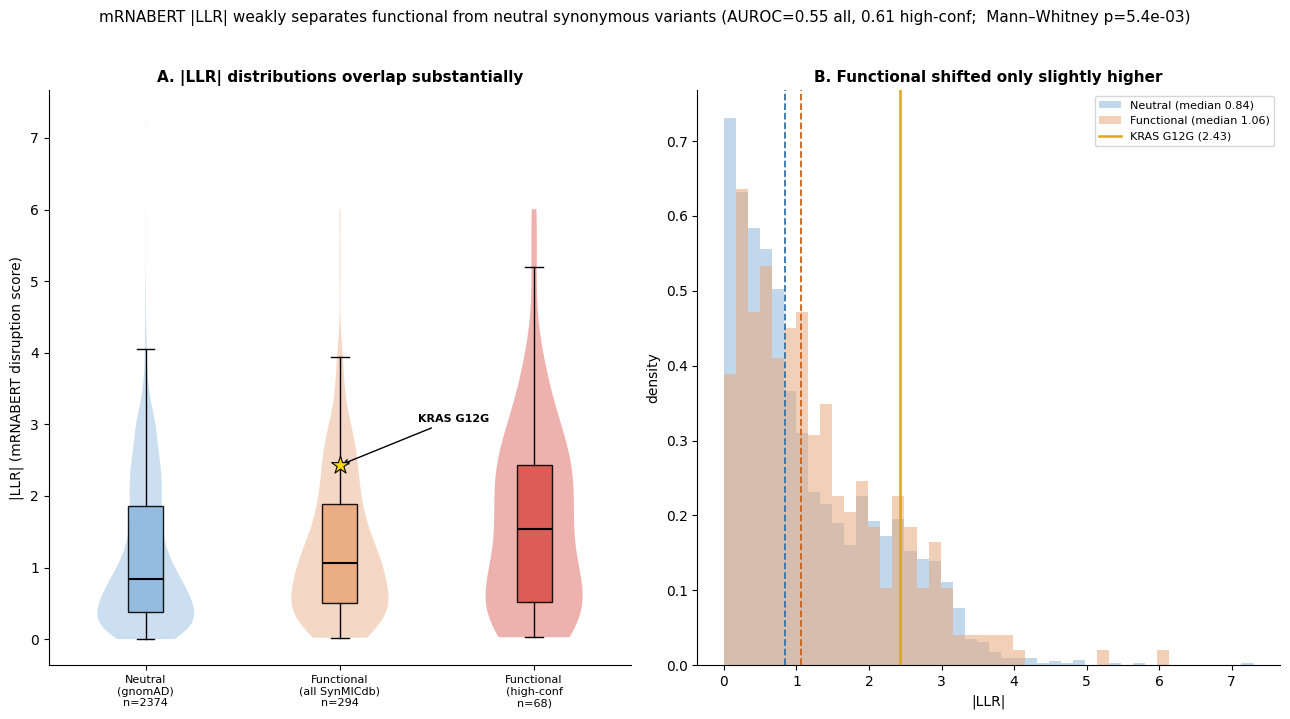

Medians — neutral: 0.836, functional: 1.058, high-conf: 1.534
AUROC all=0.546, high-conf=0.610, Mann-Whitney p=5.38e-03


In [64]:
#Test B figure: |LLR| distribution, functional vs neutral 

pos = pd.read_csv('synmicdb_scored.csv')
neg = pd.read_csv('gnomad_negatives_scored.csv')
if 'keep_splice' in pos.columns:
    pos = pos[pos['keep_splice'] == True]
pos_hi = pos[pos['synmicdb_score'] >= 4.38] #high-confidence positives 

#stats for annotation 
def auroc(p):
    y = np.r_[np.ones(len(p)), np.zeros(len(neg))]
    s = np.r_[p['abs_LLR'], neg['abs_LLR']]
    return roc_auc_score(y, s)

auc_all, auc_hi = auroc(pos), auroc(pos_hi)
U, pval = mannwhitneyu(pos['abs_LLR'], neg['abs_LLR'], alternative= 'greater')

kras = pos[(pos['gene']=='KRAS') & (pos['Mutation nt']=='c.36T>C')]
kras_val = kras['abs_LLR'].values[0] if len(kras) else None

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (13, 7))

#Panel A: violin + box, 3 groups 
groups = [neg['abs_LLR'].values, pos['abs_LLR'].values, pos_hi['abs_LLR'].values]
labels = [f'Neutral\n(gnomAD)\nn={len(neg)}', 
          f'Functional\n(all SynMICdb)\nn={len(pos)}', 
          f'Functional\n(high-conf\nn={len(pos_hi)})']
colors = ['#8FB8DE', '#E8A87C', '#D9544D']

parts = ax1.violinplot(groups, showmeans=False, showmedians=False, showextrema=False)
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c); pc.set_alpha(0.45)
bp = ax1.boxplot(groups, widths = 0.18, patch_artist=True, showfliers=False, 
                 medianprops = dict(color = 'black', lw = 1.5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.9)

#mark KRAS G12G gold anchor on the functional column
if len(kras):
    ax1.scatter([2], [kras_val], s=180, marker='*', color='gold', edgecolor='black', linewidth=0.8, zorder=5)
    ax1.annotate('KRAS G12G', xy=(2, kras_val), xytext=(2.4, kras_val+0.6), fontsize=8, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', lw=1))

ax1.set_xticks([1,2,3])
ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylabel('|LLR| (mRNABERT disruption score)', fontsize=10)
ax1.set_title('A. |LLR| distributions overlap substantially', fontsize=11, fontweight='bold')
ax1.spines[['top','right']].set_visible(False)

#Panel B: overlapping histograms
bins = np.linspace(0, max(pos['abs_LLR'].max(), neg['abs_LLR'].max()), 45)
ax2.hist(neg['abs_LLR'], bins=bins, density=True, alpha=0.55, color='#8FB8DE',
         label=f'Neutral (median {neg["abs_LLR"].median():.2f})')
ax2.hist(pos['abs_LLR'], bins=bins, density=True, alpha=0.55, color='#E8A87C',
         label=f'Functional (median {pos["abs_LLR"].median():.2f})')
ax2.axvline(neg['abs_LLR'].median(), color='#3573A8', ls='--', lw=1.3)
ax2.axvline(pos['abs_LLR'].median(), color='#C8631A', ls='--', lw=1.3)
if len(kras):
    ax2.axvline(kras_val, color='goldenrod', lw=1.8,
                label='KRAS G12G (%.2f)' % kras_val)
ax2.set_xlabel('|LLR|', fontsize=10)
ax2.set_ylabel('density', fontsize=10)
ax2.set_title('B. Functional shifted only slightly higher', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right')
ax2.spines[['top','right']].set_visible(False)

#overall caption with the honest numbers
fig.suptitle(f'mRNABERT |LLR| weakly separates functional from neutral synonymous variants '
             f'(AUROC={auc_all:.2f} all, {auc_hi:.2f} high-conf;  Mann–Whitney p={pval:.1e})',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('testB_LLR_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Medians — neutral: {neg['abs_LLR'].median():.3f}, "
      f"functional: {pos['abs_LLR'].median():.3f}, high-conf: {pos_hi['abs_LLR'].median():.3f}")
print(f"AUROC all={auc_all:.3f}, high-conf={auc_hi:.3f}, Mann-Whitney p={pval:.2e}")

In [65]:
# Confound check: per-gene AUROC (removes gene-composition effects)
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

pos = pd.read_csv('synmicdb_scored.csv')
neg = pd.read_csv('gnomad_negatives_scored.csv')
if 'keep_splice' in pos.columns:
    pos = pos[pos['keep_splice'] == True]

#Line1: per-gene |LLR| medians, to see if genes differ systematically in |LLR|
print("Per-gene |LLR| medians (pos vs neg):")
for g in sorted(set(pos['gene']) | set(neg['gene'])):
    pm = pos[pos['gene']==g]['abs_LLR'].median()
    nm = neg[neg['gene']==g]['abs_LLR'].median()
    print(f"  {g:7s} pos={pm:.3f}  neg={nm:.3f}  (npos={ (pos['gene']==g).sum():3d}, nneg={(neg['gene']==g).sum():4d})")

#Line2: AUROC computed within each gene (all positives)
print("\nPer-gene AUROC (within-gene, all SynMICdb positives):")
aurocs = []
for g in sorted(set(pos['gene'])):
    p = pos[pos['gene']==g]['abs_LLR'].values
    n = neg[neg['gene']==g]['abs_LLR'].values
    if len(p) >= 5 and len(n) >= 5: # need enough of both
        y = np.r_[np.ones(len(p)), np.zeros(len(n))]
        s = np.r_[p, n]
        a = roc_auc_score(y, s)
        aurocs.append(a)
        print(f"  {g:7s} AUROC = {a:.3f}  (npos={len(p)}, nneg={len(n)})")

#Line3: the result
print(f"\nMean within-gene AUROC: {np.mean(aurocs):.3f}")
print(f"Pooled AUROC was 0.546 — if within-gene mean is similar, gene composition is NOT the driver")
print(f"If within-gene mean is much lower, the pooled number was inflated by gene composition")

Per-gene |LLR| medians (pos vs neg):
  BRAF    pos=1.175  neg=1.320  (npos= 37, nneg= 227)
  BRCA1   pos=0.726  neg=0.631  (npos= 63, nneg= 719)
  EGFR    pos=1.074  neg=0.987  (npos= 98, nneg= 662)
  KRAS    pos=3.012  neg=2.170  (npos= 15, nneg=  78)
  PIK3CA  pos=0.533  neg=0.569  (npos= 33, nneg= 367)
  PTEN    pos=1.079  neg=0.670  (npos= 16, nneg= 139)
  TP53    pos=1.440  neg=1.122  (npos= 32, nneg= 182)

Per-gene AUROC (within-gene, all SynMICdb positives):
  BRAF    AUROC = 0.469  (npos=37, nneg=227)
  BRCA1   AUROC = 0.535  (npos=63, nneg=719)
  EGFR    AUROC = 0.504  (npos=98, nneg=662)
  KRAS    AUROC = 0.607  (npos=15, nneg=78)
  PIK3CA  AUROC = 0.497  (npos=33, nneg=367)
  PTEN    AUROC = 0.630  (npos=16, nneg=139)
  TP53    AUROC = 0.608  (npos=32, nneg=182)

Mean within-gene AUROC: 0.550
Pooled AUROC was 0.546 — if within-gene mean is similar, gene composition is NOT the driver
If within-gene mean is much lower, the pooled number was inflated by gene composition


In [66]:
#Phase4a: does mRNABERT LLR track codon usage frequency?
from scipy.stats import spearmanr

#Line1: load both scored sets and pool them (more data = cleaner estimate)
pos = pd.read_csv('synmicdb_scored.csv')
neg = pd.read_csv('gnomad_negatives_scored.csv')
allmut = pd.concat([pos, neg], ignore_index=True)
print(f"Total mutations for codon-usage analysis: {len(allmut)}")

#Line2: human codon usage per 1000 (Kazusa) -> standard Kazusa Homo sapiens values
if 'codon_freq' not in dir():
    codon_freq = {
     'TTT':17.6,'TTC':20.3,'TTA':7.7,'TTG':12.9,'CTT':13.2,'CTC':19.6,'CTA':7.2,'CTG':39.6,
     'ATT':16.0,'ATC':20.8,'ATA':7.5,'ATG':22.0,'GTT':11.0,'GTC':14.5,'GTA':7.1,'GTG':28.1,
     'TCT':15.2,'TCC':17.7,'TCA':12.2,'TCG':4.4,'CCT':17.5,'CCC':19.8,'CCA':16.9,'CCG':6.9,
     'ACT':13.1,'ACC':18.9,'ACA':15.1,'ACG':6.1,'GCT':18.4,'GCC':27.7,'GCA':15.8,'GCG':7.4,
     'TAT':12.2,'TAC':15.3,'TAA':1.0,'TAG':0.8,'CAT':10.9,'CAC':15.1,'CAA':12.3,'CAG':34.2,
     'AAT':17.0,'AAC':19.1,'AAA':24.4,'AAG':31.9,'GAT':21.8,'GAC':25.1,'GAA':29.0,'GAG':39.6,
     'TGT':10.6,'TGC':12.6,'TGA':1.6,'TGG':13.2,'CGT':4.5,'CGC':10.4,'CGA':6.2,'CGG':11.4,
     'AGT':12.1,'AGC':19.5,'AGA':12.2,'AGG':12.0,'GGT':10.8,'GGC':22.2,'GGA':16.5,'GGG':16.5}
    print("Using fallback Kazusa table")

#Line3: compute delta-frequency = freq(variant) - freq(wildtype) for each mutation
allmut['wt_freq']  = allmut['wt_codon'].map(codon_freq)
allmut['mut_freq'] = allmut['mut_codon'].map(codon_freq)
allmut['delta_freq'] = allmut['mut_freq'] - allmut['wt_freq']

#Line4: the key correlation — signed LLR vs delta-frequency
d = allmut.dropna(subset=['delta_freq','LLR'])
rho, p = spearmanr(d['LLR'], d['delta_freq'])
print(f"\nSigned LLR vs delta-codon-frequency (n={len(d)}):")
print(f"Spearman rho = {rho:+.3f}, p = {p:.2e}")

#Line5: also Pearson on the raw values, for reference
from scipy.stats import pearsonr
r, pp = pearsonr(d['LLR'], d['delta_freq'])
print(f"Pearson r = {r:+.3f}, p = {pp:.2e}")

#Line6: interpretation guide
print(f"\nIf rho is strongly positive: moving to a rarer codon (delta<0) -> negative LLR, i.e. mRNABERT does track codon usage -> the model is 'alive' and reading codon signal")
print(f"If rho is near 0: LLR is not explained by simple frequency -> model uses context beyond raw usage (could be good or could mean weak codon signal)")

Total mutations for codon-usage analysis: 2677

Signed LLR vs delta-codon-frequency (n=2677):
Spearman rho = +0.206, p = 4.77e-27
Pearson r = +0.213, p = 6.56e-29

If rho is strongly positive: moving to a rarer codon (delta<0) -> negative LLR, i.e. mRNABERT does track codon usage -> the model is 'alive' and reading codon signal
If rho is near 0: LLR is not explained by simple frequency -> model uses context beyond raw usage (could be good or could mean weak codon signal)


In [67]:
#Phase 4b: partial correlation LLR vs score, controlling codon freq
from scipy.stats import spearmanr, pearsonr

#Line1: use the positives (they have synmicdb_score); need LLR, score, delta_freq
pos = pd.read_csv('synmicdb_scored.csv')
if 'keep_splice' in pos.columns:
    pos = pos[pos['keep_splice'] == True].copy()

#Line2: recompute delta_freq for positives (same Kazusa map as before)
pos['wt_freq'] = pos['wt_codon'].map(codon_freq)
pos['mut_freq'] = pos['mut_codon'].map(codon_freq)
pos['delta_freq'] = pos['mut_freq'] - pos['wt_freq']
d = pos.dropna(subset=['LLR','synmicdb_score','delta_freq']).copy()
print(f"n = {len(d)}") 

#ine3: rank-transform (Spearman partial = Pearson partial on ranks)
x = d['LLR'].rank().to_numpy()
y = d['synmicdb_score'].rank().to_numpy()
z = d['delta_freq'].rank().to_numpy()

#residuals after removing z (codon frequency) from both x and y
rx = x - np.polyval(np.polyfit(z, x, 1), z)
ry = y - np.polyval(np.polyfit(z, y, 1), z)

raw_rho, raw_p = spearmanr(d['LLR'], d['synmicdb_score'])
freq_rho, freq_p = spearmanr(d['LLR'], d['delta_freq'])
par_r, par_p = pearsonr(rx, ry)

print(f"(1) RAW LLR vs score: rho = {raw_rho:+.3f}, p = {raw_p:.2e}")
print(f"(2) LLR vs delta_freq (confound): rho = {freq_rho:+.3f}, p = {freq_p:.2e}")
print(f"(3) PARTIAL LLR vs score | freq: r = {par_r:+.3f}, p = {par_p:.2e}")

n = 294
(1) RAW LLR vs score: rho = -0.229, p = 7.46e-05
(2) LLR vs delta_freq (confound): rho = +0.141, p = 1.54e-02
(3) PARTIAL LLR vs score | freq: r = -0.234, p = 4.94e-05


In [68]:
import RNA
print("ViennaRNA OK, version:", RNA.__version__)

ViennaRNA OK, version: 2.7.2


In [70]:
import RNA
result = RNA.fold("GGGAAACCCUUU")
print("type:", type(result), "| value:", result)

type: <class 'list'> | value: ['(((...)))...', -2.4000000953674316]


In [71]:
#Phase 4c (corrected): |LLR| vs RNAfold ΔΔG
from tqdm import tqdm

pos = pd.read_csv('synmicdb_scored.csv')
neg = pd.read_csv('gnomad_negatives_scored.csv')
allmut = pd.concat([pos, neg], ignore_index=True)
allmut['tx'] = allmut.get('transcript')
if 'transcript_scored' in allmut.columns:
    allmut['tx'] = allmut['tx'].fillna(allmut['transcript_scored'])

WINDOW = 30

def compute_ddg(tx, cds_pos, ref_base, alt_base):
    seq = cds_by_transcript.get(tx)
    if seq is None: return None
    i = cds_pos - 1
    if i < 0 or i >= len(seq) or seq[i] != ref_base: return None
    lo = max(0, i - WINDOW); hi = min(len(seq), i + WINDOW + 1)
    wt_win  = seq[lo:hi].replace('T','U')
    mut_win = (seq[lo:i] + alt_base + seq[i+1:hi]).replace('T','U')
    _, dg_wt  = RNA.fold(wt_win) # energy is element [1]
    _, dg_mut = RNA.fold(mut_win)
    return dg_mut - dg_wt

ddgs = []
for _, r in tqdm(allmut.iterrows(), total=len(allmut), desc="RNAfold ΔΔG"):
    ddgs.append(compute_ddg(r['tx'], int(r['cds_pos']), r['ref_base'], r['alt_base']))
allmut['ddG'] = ddgs
allmut['abs_ddG'] = allmut['ddG'].abs()
allmut.to_csv('mutations_with_ddG.csv', index=False)

d = allmut.dropna(subset=['ddG','LLR'])
print(f"\nComputed ΔΔG for {len(d)}/{len(allmut)} mutations")
rho_abs, p_abs = spearmanr(d['abs_LLR'], d['abs_ddG'])
rho_sgn, p_sgn = spearmanr(d['LLR'], d['ddG'])
print(f"  |LLR| vs |ΔΔG| : rho = {rho_abs:+.3f}, p = {p_abs:.2e}")
print(f"  signed LLR vs signed ΔΔG : rho = {rho_sgn:+.3f}, p = {p_sgn:.2e}")
print(f"  ΔΔG range: {d['ddG'].min():.2f} to {d['ddG'].max():.2f} kcal/mol")

RNAfold ΔΔG: 100%|██████████| 2677/2677 [00:03<00:00, 680.25it/s]


Computed ΔΔG for 2677/2677 mutations
  |LLR| vs |ΔΔG| : rho = +0.008, p = 6.85e-01
  signed LLR vs signed ΔΔG : rho = -0.050, p = 1.00e-02
  ΔΔG range: -7.20 to 6.60 kcal/mol


In [72]:
# Phase 4d: does |LLR| track codon-pair bias (di-codon context)?
from collections import Counter
from Bio.Data import CodonTable
table = CodonTable.unambiguous_dna_by_name["Standard"]

#Line1: build codon-pair expectations from CDS set (the reference corpus)
codon_counts = Counter()
pair_counts = Counter()
aa_pair_counts = Counter()
aa_counts = Counter()
for seq in cds_by_transcript.values():
    codons = [seq[i:i+3] for i in range(0, len(seq)-2, 3)]
    codons = [c for c in codons if c in table.forward_table]   # drop stops/partials
    for c in codons:
        codon_counts[c] += 1
        aa_counts[table.forward_table[c]] += 1
    for a, b in zip(codons, codons[1:]):
        pair_counts[(a,b)] += 1
        aa_pair_counts[(table.forward_table[a], table.forward_table[b])] += 1

#Line2: Codon-Pair Score (CPS, Coleman et al. 2008): log(observed / expected) -> expected pair freq from single-codon freqs, corrected for amino-acid-pair freq
total_cod = sum(codon_counts.values()); total_pair = sum(pair_counts.values())
def cps(a, b):
    if (a,b) not in pair_counts: return 0.0
    obs = pair_counts[(a,b)]
    aaA, aaB = table.forward_table[a], table.forward_table[b]
    #expected = f(a)*f(b) scaled by aa-pair / (aa_a*aa_b)
    exp = (codon_counts[a]*codon_counts[b]/total_cod) * \
          (aa_pair_counts[(aaA,aaB)] / (aa_counts[aaA]*aa_counts[aaB]/sum(aa_counts.values())))
    return np.log(obs/exp) if exp>0 else 0.0

#Line3: for each mutation, ΔCPS over the two pairs touching the mutated codon
allmut = pd.read_csv('mutations_with_ddG.csv')   #already has LLR + tx + positions
def delta_cps(tx, ci, wt_codon, mut_codon):
    seq = cds_by_transcript.get(tx)
    if seq is None: 
        return None
    codons = [seq[i:i+3] for i in range(0, len(seq)-2, 3)]
    if ci<0 or ci>=len(codons) or codons[ci]!=wt_codon: 
        return None
    prev_c = codons[ci-1] if ci>0 else None
    next_c = codons[ci+1] if ci+1<len(codons) else None
    d = 0.0
    if prev_c and prev_c in table.forward_table:
        d += cps(prev_c, mut_codon) - cps(prev_c, wt_codon)
    if next_c and next_c in table.forward_table:
        d += cps(mut_codon, next_c) - cps(wt_codon, next_c)
    return d

dcps = []
for _, r in allmut.iterrows():
    dcps.append(delta_cps(r['tx'], int(r['codon_index']), r['wt_codon'], r['mut_codon']))
allmut['delta_cps'] = dcps

#Line4: correlate LLR with codon-pair change
d = allmut.dropna(subset=['delta_cps','LLR'])
rho_s, p_s = spearmanr(d['LLR'], d['delta_cps'])
rho_a, p_a = spearmanr(d['abs_LLR'], d['delta_cps'].abs())
print(f"n = {len(d)}")
print(f"signed LLR vs ΔCPS : rho = {rho_s:+.3f}, p = {p_s:.2e}")
print(f"|LLR| vs |ΔCPS| : rho = {rho_a:+.3f}, p = {p_a:.2e}")

n = 2677
signed LLR vs ΔCPS : rho = +0.059, p = 2.07e-03
|LLR| vs |ΔCPS| : rho = +0.065, p = 7.77e-04


In [73]:
# Phase 4e: позиция в CDS и GC-состав

allmut = pd.read_csv('mutations_with_ddG.csv') # уже есть LLR, tx, codon_index, cds_pos, codons

WINDOW = 30  # то же окно ±30 нт, что для ΔΔG

def features(tx, cds_pos, ci, wt_codon, mut_codon):
    seq = cds_by_transcript.get(tx)
    if seq is None: 
        return (None, None, None, None)
    n_codons = len(seq)//3
    #(1)относительная позиция кодона в CDS: 0 = старт, 1 = конец -> гипотеза "ramp" = особая динамика в начале гена 
    rel_pos = ci / n_codons if n_codons else None
    #(2)GC-состав окна ±30 нт вокруг мутации (wildtype)
    i = cds_pos - 1
    lo, hi = max(0, i-WINDOW), min(len(seq), i+WINDOW+1)
    win = seq[lo:hi]
    gc_win = (win.count('G')+win.count('C'))/len(win) if win else None
    #(3)изменение GC от самой мутации: меняется ли G/C на A/T или наоборот
    wt_gc  = wt_codon.count('G')+wt_codon.count('C')
    mut_gc = mut_codon.count('G')+mut_codon.count('C')
    delta_gc = mut_gc - wt_gc  # -1, 0, +1 обычно
    return rel_pos, gc_win, delta_gc, abs(delta_gc)

rows = [features(r['tx'], int(r['cds_pos']), int(r['codon_index']), r['wt_codon'], r['mut_codon'])
        for _, r in allmut.iterrows()]
allmut[['rel_pos','gc_window','delta_gc','abs_delta_gc']] = pd.DataFrame(rows, index=allmut.index)

#корреляции каждого признака с LLR / |LLR|
print(f"n = {len(allmut.dropna(subset=['LLR']))}\n")
def report(feat, target, label):
    d = allmut.dropna(subset=[feat, target])
    rho, p = spearmanr(d[target], d[feat])
    print(f"{label:32s}: rho = {rho:+.3f}, p = {p:.2e}")

print("Позиция в CDS:")
report('rel_pos', 'abs_LLR', '|LLR| vs позиция (0=старт,1=конец)')
report('rel_pos', 'LLR', 'signed LLR vs позиция')
print("\nGC-состав:")
report('gc_window', 'abs_LLR', '|LLR| vs GC окна ±30нт')
report('delta_gc', 'LLR', 'signed LLR vs ΔGC (мутации)')
report('abs_delta_gc', 'abs_LLR', '|LLR| vs |ΔGC|')

n = 2677

Позиция в CDS:
|LLR| vs позиция (0=старт,1=конец): rho = -0.029, p = 1.32e-01
signed LLR vs позиция           : rho = -0.006, p = 7.61e-01

GC-состав:
|LLR| vs GC окна ±30нт          : rho = +0.120, p = 3.99e-10
signed LLR vs ΔGC (мутации)     : rho = -0.244, p = 1.48e-37
|LLR| vs |ΔGC|                  : rho = +0.119, p = 6.63e-10


In [74]:
#is ΔGC independent of codon frequency, or the same signal?

d = allmut.copy()
d['wt_freq']  = d['wt_codon'].map(codon_freq)
d['mut_freq'] = d['mut_codon'].map(codon_freq)
d['delta_freq'] = d['mut_freq'] - d['wt_freq']
d = d.dropna(subset=['LLR','delta_gc','delta_freq'])

#how correlated are the two explanations with each other?
rho_link, _ = spearmanr(d['delta_gc'], d['delta_freq'])
print(f"ΔGC vs Δfreq: rho = {rho_link:+.3f}")

#partial: LLR vs ΔGC, controlling for codon frequency
x = d['LLR'].rank().values; y = d['delta_gc'].rank().values; z = d['delta_freq'].rank().values
rx = x - np.polyval(np.polyfit(z,x,1), z)
ry = y - np.polyval(np.polyfit(z,y,1), z)
par, pp = pearsonr(rx, ry)
raw, _ = spearmanr(d['LLR'], d['delta_gc'])
print(f"LLR vs ΔGC  raw: {raw:+.3f}   partial (controlling freq): {par:+.3f}")

ΔGC vs Δfreq: rho = +0.511
LLR vs ΔGC  raw: -0.244   partial (controlling freq): -0.415


In [75]:
# Phase 4f: multivariate confirmation of the ΔGC suppression effect
import statsmodels.api as sm
from scipy.stats import zscore

d = allmut.copy()
d['wt_freq']  = d['wt_codon'].map(codon_freq)
d['mut_freq'] = d['mut_codon'].map(codon_freq)
d['delta_freq'] = d['mut_freq'] - d['wt_freq']
d = d.dropna(subset=['LLR','delta_freq','delta_gc']).copy()

#Line1: standardize predictors & outcome (z-scores) so coefficients are comparable betas
d['z_LLR'] = zscore(d['LLR'])
d['z_freq'] = zscore(d['delta_freq'])
d['z_gc'] = zscore(d['delta_gc'])

#Line2: model A — frequency alone (baseline)
mA = sm.OLS(d['z_LLR'], sm.add_constant(d[['z_freq']])).fit()

#Line3: model B — GC alone
mB = sm.OLS(d['z_LLR'], sm.add_constant(d[['z_gc']])).fit()

#Line4: model C — both together (the key model)
mC = sm.OLS(d['z_LLR'], sm.add_constant(d[['z_freq','z_gc']])).fit()

print(f"n = {len(d)}\n")
print(f"Model A (freq only): R² = {mA.rsquared:.4f} | β_freq = {mA.params['z_freq']:+.3f}")
print(f"Model B (GC only): R² = {mB.rsquared:.4f} | β_gc = {mB.params['z_gc']:+.3f}")
print(f"Model C (both): R² = {mC.rsquared:.4f}")
print(f"β_freq = {mC.params['z_freq']:+.3f} (p={mC.pvalues['z_freq']:.1e})")
print(f"β_gc = {mC.params['z_gc']:+.3f} (p={mC.pvalues['z_gc']:.1e})")

#Line5: the suppression check — does each predictor's strength change when combined?
print(f"\nSuppression check:")
print(f"freq β: alone {mA.params['z_freq']:+.3f} -> with GC {mC.params['z_freq']:+.3f}")
print(f"GC β: alone {mB.params['z_gc']:+.3f} -> with freq {mC.params['z_gc']:+.3f}")

n = 2677

Model A (freq only): R² = 0.0455 | β_freq = +0.213
Model B (GC only): R² = 0.0645 | β_gc = -0.254
Model C (both): R² = 0.2203
β_freq = +0.457 (p=6.9e-108)
β_gc = -0.484 (p=1.3e-119)

Suppression check:
freq β: alone +0.213 -> with GC +0.457
GC β: alone -0.254 -> with freq -0.484
